In [1]:
# Install the requests-cache library.

!pip install requests-cache

                                              0.0/60.3 kB ? eta -:--:--
     ---------------------------------------- 60.3/60.3 kB 3.3 MB/s eta 0:00:00
                                              0.0/57.5 kB ? eta -:--:--
     ---------------------------------------- 57.5/57.5 kB 3.0 MB/s eta 0:00:00
                                              0.0/61.2 kB ? eta -:--:--
     ---------------------------------------- 61.2/61.2 kB 3.2 MB/s eta 0:00:00
  Attempting uninstall: attrs
    Found existing installation: attrs 21.4.0
    Uninstalling attrs-21.4.0:
      Successfully uninstalled attrs-21.4.0


In [2]:
# Import libraries.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import requests
import requests_cache
import seaborn as sns

# Import objects.

from geopy.geocoders import GoogleV3
from scipy.stats import uniform
from sklearn import metrics
from sklearn import tree
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense
from sklearn.metrics import r2_score


ModuleNotFoundError: No module named 'geopy'

## Initial Dataset Preparation

In [3]:
# Mount the drive.

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# Load the data from the spreadsheet.
#
# dfc - the coffee sales
# dfs - the stores

#dfc = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/coffee_sales_data.xlsx", sheet_name = 0, skiprows= 0, header = 0)
#dfs = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/coffee_sales_data.xlsx", sheet_name = 1, skiprows= 0, header = 0)

#file_path = "/content/drive/MyDrive/Colab Notebooks/coffee_sales_data.xlsx"
file_path = "./coffee_sales_data.xlsx"

try:
    dfc = pd.read_excel(file_path, sheet_name=0, skiprows=0, header=0)
    dfs = pd.read_excel(file_path, sheet_name=1, skiprows=0, header=0)
except FileNotFoundError:
    # If the file is not found, attempt to read from another location
    new_file_path = "/content/Sales Data2.xlsx"
    try:
        dfc = pd.read_excel(new_file_path, sheet_name=0, skiprows=0, header=0)
        dfs = pd.read_excel(new_file_path, sheet_name=1, skiprows=0, header=0)
    except FileNotFoundError:
        print("Both file paths are incorrect. File not found.")
    else:
        print("Data loaded from the alternative file path:", new_file_path)
else:
    print("Data loaded from the original file path:", file_path)




Data loaded from the original file path: ./coffee_sales_data.xlsx


In [5]:
# Display the data types for the coffee dataframe.

dfc.dtypes

ITEM                int64
ASSORTMENT_END     object
DESCR              object
Store               int64
SOURCE             object
                   ...   
PERIOD101         float64
PERIOD102         float64
PERIOD103         float64
PERIOD104         float64
PERIOD105         float64
Length: 62, dtype: object

In [6]:
# Display the data types for the stores dataframe.

dfs.dtypes

Store             int64
U_CITY_NM        object
U_PROV_CD        object
U_FCST_REGION    object
U_COUNTRY        object
Size             object
dtype: object

In [7]:
# Quick look at the coffee sales data.

dfc.head()

,ITEM,ASSORTMENT_END,DESCR,Store,SOURCE,TYPE,PERIOD50,PERIOD51,PERIOD52,PERIOD53,...,PERIOD96,PERIOD97,PERIOD98,PERIOD99,PERIOD100,PERIOD101,PERIOD102,PERIOD103,PERIOD104,PERIOD105
0,20026954001,9999-12-31 00:00:00,TASSIMO MH HOUSE BLEND,99,WAREHOUSE,1,6.0,6.0,2.0,8.0,...,1.0,2.0,3.0,1.0,7.0,13.0,NaN,2.0,NaN,2.0
1,20026954001,9999-12-31 00:00:00,TASSIMO MH HOUSE BLEND,100,WAREHOUSE,1,15.0,2.0,NaN,NaN,...,1.0,3.0,10.0,NaN,10.0,11.0,NaN,6.0,NaN,NaN
2,20026954001,9999-12-31 00:00:00,TASSIMO MH HOUSE BLEND,101,WAREHOUSE,1,5.0,4.0,6.0,6.0,...,NaN,2.0,5.0,6.0,3.0,6.0,3.0,NaN,1.0,2.0
3,20026954001,9999-12-31 00:00:00,TASSIMO MH HOUSE BLEND,102,WAREHOUSE,1,6.0,7.0,10.0,6.0,...,2.0,4.0,7.0,1.0,6.0,8.0,NaN,1.0,2.0,NaN
4,20026954001,9999-12-31 00:00:00,TASSIMO MH HOUSE BLEND,103,WAREHOUSE,1,2.0,9.0,2.0,4.0,...,NaN,5.0,5.0,NaN,4.0,10.0,5.0,NaN,NaN,4.0


In [8]:
# Quick look at the store data.

dfs.head()

,Store,U_CITY_NM,U_PROV_CD,U_FCST_REGION,U_COUNTRY,Size
0,1,Wasaga Beach,ON,ON,CA,Average
1,2,St Thomas,ON,ON,CA,Average
2,3,Chatham,ON,ON,CA,Average
3,4,Leamington,ON,ON,CA,Average
4,5,Windsor,ON,ON,CA,Average


In [9]:
# Merge the two dataframes based on the Store field.  Merge as an outer join.

df = dfc.merge(dfs, left_on='Store', right_on='Store', how='outer')

In [10]:
df.head()

,ITEM,ASSORTMENT_END,DESCR,Store,SOURCE,TYPE,PERIOD50,PERIOD51,PERIOD52,PERIOD53,...,PERIOD101,PERIOD102,PERIOD103,PERIOD104,PERIOD105,U_CITY_NM,U_PROV_CD,U_FCST_REGION,U_COUNTRY,Size
0,2.002695e+10,9999-12-31 00:00:00,TASSIMO MH HOUSE BLEND,99,WAREHOUSE,1.0,6.000000,6.000000,2.000000,8.000000,...,13.00000,NaN,2.000000,NaN,2.000000,Ottawa,ON,ON,CA,Average
1,2.005750e+07,9999-12-31 00:00:00,NO NAME INSTANT COFFEE CP,99,WAREHOUSE,1.0,9.052923,9.151315,9.137049,8.680748,...,1.42514,3.75237,7.957689,8.002362,7.890318,Ottawa,ON,ON,CA,Average
2,2.005750e+07,9999-12-31 00:00:00,NO NAME INSTANT COFFEE CP,99,WAREHOUSE,1.0,8.000000,7.000000,6.000000,10.000000,...,23.00000,14.00000,8.000000,9.000000,14.000000,Ottawa,ON,ON,CA,Average
3,2.006787e+07,9999-12-31 00:00:00,JACOBS COFFEE KRONUNG,99,WAREHOUSE,1.0,1.000000,12.000000,2.000000,5.000000,...,6.00000,1.00000,5.000000,4.000000,NaN,Ottawa,ON,ON,CA,Average
4,2.007417e+10,9999-12-31 00:00:00,NABOB ORGANIC GOURMET BLEND,99,WAREHOUSE,1.0,5.000000,NaN,1.000000,6.000000,...,5.00000,2.00000,2.000000,2.000000,NaN,Ottawa,ON,ON,CA,Average


In [11]:
# Change column names to be more user friendly.

df = df.rename(columns={'DESCR' : 'Coffee_Product', 'U_CITY_NM' : 'City', 'U_PROV_CD' : 'Province', 'U_FCST_REGION' : 'Region', 'U_COUNTRY' : 'Country'})

In [12]:
# Calculate the total sales for each product.

df['Total_Sales']=df.loc[:,'PERIOD50':'PERIOD105'].sum(axis=1)

In [13]:
# Quick look at the new columns.

df.columns

Index(['ITEM', 'ASSORTMENT_END', 'Coffee_Product', 'Store', 'SOURCE', 'TYPE',
       'PERIOD50', 'PERIOD51', 'PERIOD52', 'PERIOD53', 'PERIOD54', 'PERIOD55',
       'PERIOD56', 'PERIOD57', 'PERIOD58', 'PERIOD59', 'PERIOD60', 'PERIOD61',
       'PERIOD62', 'PERIOD63', 'PERIOD64', 'PERIOD65', 'PERIOD66', 'PERIOD67',
       'PERIOD68', 'PERIOD69', 'PERIOD70', 'PERIOD71', 'PERIOD72', 'PERIOD73',
       'PERIOD74', 'PERIOD75', 'PERIOD76', 'PERIOD77', 'PERIOD78', 'PERIOD79',
       'PERIOD80', 'PERIOD81', 'PERIOD82', 'PERIOD83', 'PERIOD84', 'PERIOD85',
       'PERIOD86', 'PERIOD87', 'PERIOD88', 'PERIOD89', 'PERIOD90', 'PERIOD91',
       'PERIOD92', 'PERIOD93', 'PERIOD94', 'PERIOD95', 'PERIOD96', 'PERIOD97',
       'PERIOD98', 'PERIOD99', 'PERIOD100', 'PERIOD101', 'PERIOD102',
       'PERIOD103', 'PERIOD104', 'PERIOD105', 'City', 'Province', 'Region',
       'Country', 'Size', 'Total_Sales'],
      dtype='object')

In [14]:
df.duplicated().sum()

511

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
start_column = "PERIOD105"

num_months = 14
column_sets = []

# Generate sets of four columns in descending order to make months
current_column = start_column
for _ in range(num_months):
    column_sets.append([f'PERIOD{i}' for i in range(int(current_column[6:]), int(current_column[6:]) - 4, -1)])
    current_column = f'PERIOD{int(current_column[6:]) - 4}' if int(current_column[6:]) - 4 >= 50 else None

# Defining month names with the year in descending order to label the features
month_names = [
    "Nov_2023", "Oct_2023", "Sep_2023", "Aug_2023", "Jul_2023", "Jun_2023",
    "May_2023", "Apr_2023", "Mar_2023", "Feb_2023", "Jan_2023", "Dec_2022","Nov_2022",
    "Sep_2022"
]

# Iterate through the column sets and month names:
for i, (columns, month_name) in enumerate(zip(column_sets, month_names), start=1):
    new_column_name = f'{month_name}'
    df[new_column_name] = df[columns].sum(axis=1)


print(df)


               ITEM       ASSORTMENT_END               Coffee_Product  Store  \
0      2.002695e+10  9999-12-31 00:00:00       TASSIMO MH HOUSE BLEND     99   
1      2.005750e+07  9999-12-31 00:00:00    NO NAME INSTANT COFFEE CP     99   
2      2.005750e+07  9999-12-31 00:00:00    NO NAME INSTANT COFFEE CP     99   
3      2.006787e+07  9999-12-31 00:00:00        JACOBS COFFEE KRONUNG     99   
4      2.007417e+10  9999-12-31 00:00:00  NABOB ORGANIC GOURMET BLEND     99   
...             ...                  ...                          ...    ...   
87174           NaN                  NaN                          NaN      3   
87175           NaN                  NaN                          NaN      4   
87176           NaN                  NaN                          NaN      5   
87177           NaN                  NaN                          NaN      6   
87178           NaN                  NaN                          NaN      7   

          SOURCE  TYPE  PERIOD50   PERI

In [17]:
# Take a copy of the dataframe just in case we need to revert.

df_copy = df

In [18]:
# To revert back to the copy, uncomment the following.

#  df = df_copy

## Exploratory Data Analysis

### Data Cleaning

In [19]:
# Take a look at the shape of the merged dataframe.

df.shape

(86668, 82)

In [20]:
# Check for empty data fields.

df.loc[:, :'TYPE'].isnull().sum()

ITEM              7
ASSORTMENT_END    7
Coffee_Product    7
Store             0
SOURCE            7
TYPE              7
dtype: int64

In [21]:
# As there are only 7 records from 87K that do not contain data, just remove them.
# They are most likely all from the same records so just use the ITEM as the
# subset instead of all of the columns.

df.dropna(subset=['ITEM'], inplace=True)

In [22]:
# Check for empty data fields in the Store info.

df.loc[:, 'City':'Size'].isnull().sum()

City        0
Province    0
Region      0
Country     0
Size        0
dtype: int64

All Store information is available so no records need to be dropped or imputed.

In [23]:
# Check for empty data fields in Period columns.

df.loc[:, 'PERIOD50':'PERIOD60'].isnull().sum()

PERIOD50    24886
PERIOD51    24220
PERIOD52    23839
PERIOD53    23846
PERIOD54    22984
PERIOD55    22991
PERIOD56    22392
PERIOD57    21241
PERIOD58    26028
PERIOD59    25182
PERIOD60    24680
dtype: int64

In [24]:
# There are a lot of missing values.  Therefore, instead of dropping these
# rows (~1/4 of the dataset), just impute that the values for these is '0'.

df = df.fillna(0)

In [25]:
# Final check.

df.isnull().sum()

ITEM              0
ASSORTMENT_END    0
Coffee_Product    0
Store             0
SOURCE            0
                 ..
Feb_2023          0
Jan_2023          0
Dec_2022          0
Nov_2022          0
Sep_2022          0
Length: 82, dtype: int64

In [26]:
# Check to see if larger store size has larger sales:
store_size = df.groupby(['Size'])['Total_Sales'].median().sort_values(ascending=False)
store_size

Size
Large      179.080823
Average    159.003038
Small      126.907555
Name: Total_Sales, dtype: float64

In [27]:
# Top 5 cities with the most coffee sales
city_median = df.groupby(['Province', 'City'])['Total_Sales'].median().sort_values(ascending=False)
city_median.head()

Province  City         
BC        Kelowna          277.071634
          Langley          241.000000
          Chilliwack       235.500000
          Prince George    227.500000
          Nanaimo          225.000000
Name: Total_Sales, dtype: float64

In [28]:
# Top 5 cities with the least coffee sales
city_median = df.groupby(['Province', 'City'])['Total_Sales'].median().sort_values(ascending=False)
city_median.tail()

Province  City         
ON        Toronto          111.00000
SK        Prince Albert    110.33081
ON        Mississauga      107.00000
AB        Camrose          106.00000
ON        Ajax             102.00000
Name: Total_Sales, dtype: float64

In [61]:
#prov_total = dfs.groupby(['U_PROV_CD'])['Store'].value_counts().sort_values(ascending=False)
#prov_total
prov_stores_df = dfs['U_PROV_CD'].value_counts()
prov_stores_df

ON    38
AB    34
BC    28
MB    11
SK     8
YT     1
Name: U_PROV_CD, dtype: int64

In [55]:
# Top provinces by coffee sales

# suppress scientific notation by setting float_format
pd.options.display.float_format = '{:.0f}'.format

prov_total = df.groupby(['Province'])['Total_Sales'].sum().sort_values(ascending=False)
prov_total

Province
AB   3985000
BC   3747563
ON   2713571
MB   1492193
SK    909516
YT    135580
Name: Total_Sales, dtype: float64

In [29]:
# Determine how many different types of coffee-related products there are.

df['Coffee_Product'].value_counts()

TIMH ORIGINAL K COMP              387
PC TEA ORANGE PEKOE               384
PC TEA CHOCOLATE MINT             299
LVZZ K CUP SELEZIONE              281
CELEST FRUIT SAMPLER              275
                                 ... 
WISSOTZKY GINGER CITRUS W/NANA      1
WISSOTZKY TEA LEMON WITH NANA       1
WISSOTZKY TEA STRAWBERRY BURST      1
WISSOTZKY GRN WILDBRY PASSION       1
TIMH K CUP COLOMBIAN                1
Name: Coffee_Product, Length: 829, dtype: int64

In [30]:
df.drop(df[df['Coffee_Product'].str.contains('tea|milk|choc|syrup|cocoa|Tetley|Ovaltine|CHAI|NIJI|APPLE|GINGER|COCONUT|EAGLE|SORREL|HC|CONDENSED|GNGR|WISSOTZKY|HORLICKS|PENSAL|WHITENER|CELEST|HERBAL|PEPPERMINT|CHO|CAMOMILE|HEBAL|CREAMY|CREAMER|SOYA|THICKENED',
                                             case=False, regex=True)].index, inplace=True)
#dropping all tea and milk products in data

In [31]:
# Determine how many actual types of coffee products there are.

df['Coffee_Product'].value_counts()

TIMH ORIGINAL K COMP              387
LVZZ K CUP SELEZIONE              281
NSCAFE RICH DCAF JAR              274
PC SUMATRAN SIGL COFFEE POD       273
STBU CAFFE VERONA                 272
                                 ... 
JACOBS CRONAT GOLD INSTAN COF       1
BLZC DRK AFFAIR GRND CFFEE CAN      1
WALDEN FARMS COFE CREMR HAZLNT      1
ELIT PLATINUM DRIED INST COF        1
TIMH K CUP COLOMBIAN                1
Name: Coffee_Product, Length: 429, dtype: int64

In [41]:
#df['Total_Sales'].sum()
#df['Total_Sales'] = np.where(df['Coffee_Product'] == 'TIMH ORIGINAL K COMP').sum(axis=1), 0)
cdf = df.loc[df['Coffee_Product'] == 'NESCAFE COFFEE INSTNT RICH BLND']
cdf['Total_Sales'].sum()

# TIMH ORIGINAL K COMP =           188124
# LVZZ K CUP SELEZIONE =            23606
# NSCAFE RICH DCAF JAR =           223552
# PC SUMATRAN SIGL COFFEE POD =     21299
# STBU CAFFE VERONA =               48479
# MH EZO TIN ORIGINAL ROAST =      415287
# NESCAFE COFFEE INSTNT RICH BLND= 324814

324814.0

In [53]:
df.groupby('Coffee_Product').Total_Sales.agg(['sum']).sort_values(by = ['sum'], ascending=False)

,sum
Coffee_Product,
MH EZO TIN ORIGINAL ROAST,415287.000000
NESCAFE COFFEE INSTNT RICH BLND,324814.000000
PC COFFEE WEST COAST DARK,321705.000000
FOLGERS CLSC RST GRD COFFEE,261460.000000
NABOB TRAD COFFEE FINE GRND CP,251602.205833
...,...
ZLATNA TURKISH CAFE,5.000000
WALDEN FARMS COFE CREMR HAZLNT,1.000000
WALDEN FARMS COFFE CRMR FR VAN,1.000000


Check to see what impact removing non-coffee products had on the dataset.

In [32]:
# Check to see if larger store size has larger sales:
store_size = df.groupby(['Size'])['Total_Sales'].median().sort_values(ascending=False)
store_size

Size
Large      142.0
Average    133.0
Small      103.0
Name: Total_Sales, dtype: float64

In [33]:
# Top 5 cities with the most coffee sales
city_median = df.groupby(['Province', 'City'])['Total_Sales'].median().sort_values(ascending=False)
city_median.head()

Province  City        
BC        Langley         209.0
          Kelowna         208.5
          Chilliwack      206.0
ON        Thunder Bay     193.0
AB        Spruce Grove    193.0
Name: Total_Sales, dtype: float64

In [34]:
# Top 5 cities with the least coffee sales
city_median = df.groupby(['Province', 'City'])['Total_Sales'].median().sort_values(ascending=False)
city_median.tail()

Province  City         
ON        Oshawa           98.000000
          Mississauga      97.000000
AB        Camrose          96.000000
SK        Prince Albert    93.850272
ON        Ajax             87.591871
Name: Total_Sales, dtype: float64

The sales volumes were lower, of course, removing all of the non-coffee products.  However, the top 3 cities by and large stayed the same.

In [35]:
# Create a new Total_Sales column with the total amount from all Periods.

#df['Total_Sales']=df.loc[:,'PERIOD50':'PERIOD105'].sum(axis=1)

In [36]:
# See how many records are left in the dataset after removing non-coffee
# products (e.g., tea, milk, syrup).

df.shape

(52004, 82)

### Data Exploration

In [37]:
# See what cities are in the data set.

df['City'].value_counts()

Calgary           5982
Edmonton          4611
Winnipeg          3738
Toronto           2007
Surrey            1396
                  ... 
Campbell River     438
Ajax               436
Steinbach          436
Peterborough       432
Windsor            425
Name: City, Length: 70, dtype: int64

In [38]:
# See what provinces are in the data set.

df['Province'].value_counts()

AB    15643
ON    14213
BC    12952
MB     5089
SK     3659
YT      448
Name: Province, dtype: int64

In [39]:
# Examine the basic statistical information for the Period features.

df.loc[:, "PERIOD50":"PERIOD105"].describe()


,PERIOD50,PERIOD51,PERIOD52,PERIOD53,PERIOD54,PERIOD55,PERIOD56,PERIOD57,PERIOD58,PERIOD59,...,PERIOD96,PERIOD97,PERIOD98,PERIOD99,PERIOD100,PERIOD101,PERIOD102,PERIOD103,PERIOD104,PERIOD105
count,52004.000000,52004.000000,52004.000000,52004.000000,52004.000000,52004.000000,52004.000000,52004.000000,52004.000000,52004.000000,...,52004.000000,52004.000000,52004.000000,52004.000000,52004.000000,52004.000000,52004.000000,52004.000000,52004.000000,52004.000000
mean,4.349680,4.473254,4.543020,4.320707,4.675983,4.635950,4.914962,5.476689,3.936683,4.356559,...,4.472466,4.942489,5.420324,4.359184,5.397535,5.564279,4.899589,4.823731,4.847587,4.807979
std,8.455495,8.235386,8.914030,7.971050,8.837337,9.104908,10.242210,9.695818,8.969353,9.677651,...,8.384407,9.303364,10.403056,9.312294,17.042495,20.057888,9.623848,8.780158,9.215512,8.756817
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.976673,1.000000
50%,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,1.917499,2.000000,...,2.000000,2.000000,2.159596,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
75%,5.000000,6.000000,5.778924,5.000000,6.000000,5.364769,6.000000,6.799582,4.000000,5.000000,...,5.000000,6.000000,6.000000,5.000000,5.537379,6.000000,5.160518,5.321149,5.000000,5.000000
max,214.000000,195.000000,253.000000,208.000000,316.000000,310.000000,468.000000,321.000000,290.000000,328.000000,...,268.000000,224.000000,281.000000,278.000000,628.000000,804.000000,279.000000,290.000000,231.000000,233.000000


In [40]:
# Examine the basic statistical information for the Month features.

df.loc[:, "Nov_2023":"Sep_2022"].describe()

,Nov_2023,Oct_2023,Sep_2023,Aug_2023,Jul_2023,Jun_2023,May_2023,Apr_2023,Mar_2023,Feb_2023,Jan_2023,Dec_2022,Nov_2022,Sep_2022
count,52004.000000,52004.000000,52004.000000,52004.000000,52004.000000,52004.000000,52004.000000,52004.000000,52004.000000,52004.000000,52004.000000,52004.000000,52004.000000,52004.000000
mean,19.378886,20.741322,18.642147,17.001113,16.407971,17.478779,17.529724,18.323340,14.168415,18.481274,17.200622,16.918148,19.703585,17.686662
std,33.598227,50.926030,32.477801,29.592658,29.557385,31.151576,34.063969,35.291889,27.741462,36.759676,32.631233,30.221179,33.479177,29.969872
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,3.000000,3.574400,3.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.029952,2.000000,2.000000,1.854340
50%,10.000000,9.672811,10.000000,9.000000,9.000000,8.372495,8.000000,9.000000,7.000000,9.000000,8.466621,8.377425,10.000000,9.000000
75%,21.000000,21.365338,21.000000,19.000000,18.069707,20.000000,18.000000,20.000000,16.000000,20.000000,19.000000,19.000000,23.000000,21.000000
max,1000.000000,1720.000000,682.000000,744.000000,702.000000,1137.000000,1035.000000,1135.000000,495.000000,1196.000000,986.000000,662.000000,1135.000000,647.000000


The median, per month, is very similar across all months.  However, the max suggests that a large amount of coffee is sold each month.

In [41]:
# Look at the dataset for the highest sales in November 2023.

df[df['Nov_2023'] == df["Nov_2023"].max()]

,ITEM,ASSORTMENT_END,Coffee_Product,Store,SOURCE,TYPE,PERIOD50,PERIOD51,PERIOD52,PERIOD53,...,Jul_2023,Jun_2023,May_2023,Apr_2023,Mar_2023,Feb_2023,Jan_2023,Dec_2022,Nov_2022,Sep_2022
20465,20873036.0,9999-12-31 00:00:00,NESCAFE COFFEE INSTNT RICH BLND,31,WAREHOUSE,1.0,213.0,67.0,63.0,208.0,...,628.0,670.0,794.0,1092.0,427.0,1196.0,986.0,660.0,1135.0,551.0


In [42]:
# Which City and Store did the highest Total Sales in November 2023.

df_max = df[df['Nov_2023'] == df["Nov_2023"].max()]
df_max[["City", "Store", "Size"]]

,City,Store,Size
20465,Vancouver,31,Average


Vancouver!

In [43]:
# Examine the basic statistical information for the Target.

df['Total_Sales'].describe()

count    52004.000000
mean       249.661990
std        419.455624
min          0.000000
25%         61.000000
50%        133.785007
75%        270.078942
max      10461.000000
Name: Total_Sales, dtype: float64

If the median total sales is 133 and at the 75th percentile, it is 270, which store did 10,461 in sales?  Let's find out.

In [44]:
# Look at the dataset for the highest sales Total Sales.

df[df['Total_Sales'] == df["Total_Sales"].max()]

,ITEM,ASSORTMENT_END,Coffee_Product,Store,SOURCE,TYPE,PERIOD50,PERIOD51,PERIOD52,PERIOD53,...,Jul_2023,Jun_2023,May_2023,Apr_2023,Mar_2023,Feb_2023,Jan_2023,Dec_2022,Nov_2022,Sep_2022
20465,20873036.0,9999-12-31 00:00:00,NESCAFE COFFEE INSTNT RICH BLND,31,WAREHOUSE,1.0,213.0,67.0,63.0,208.0,...,628.0,670.0,794.0,1092.0,427.0,1196.0,986.0,660.0,1135.0,551.0


In [45]:
# Which City and Store did the highest Total Sales.

df_max = df[df['Total_Sales'] == df["Total_Sales"].max()]
df_max[["City", "Store", "Size"]]


,City,Store,Size
20465,Vancouver,31,Average


Vancouver... of course!

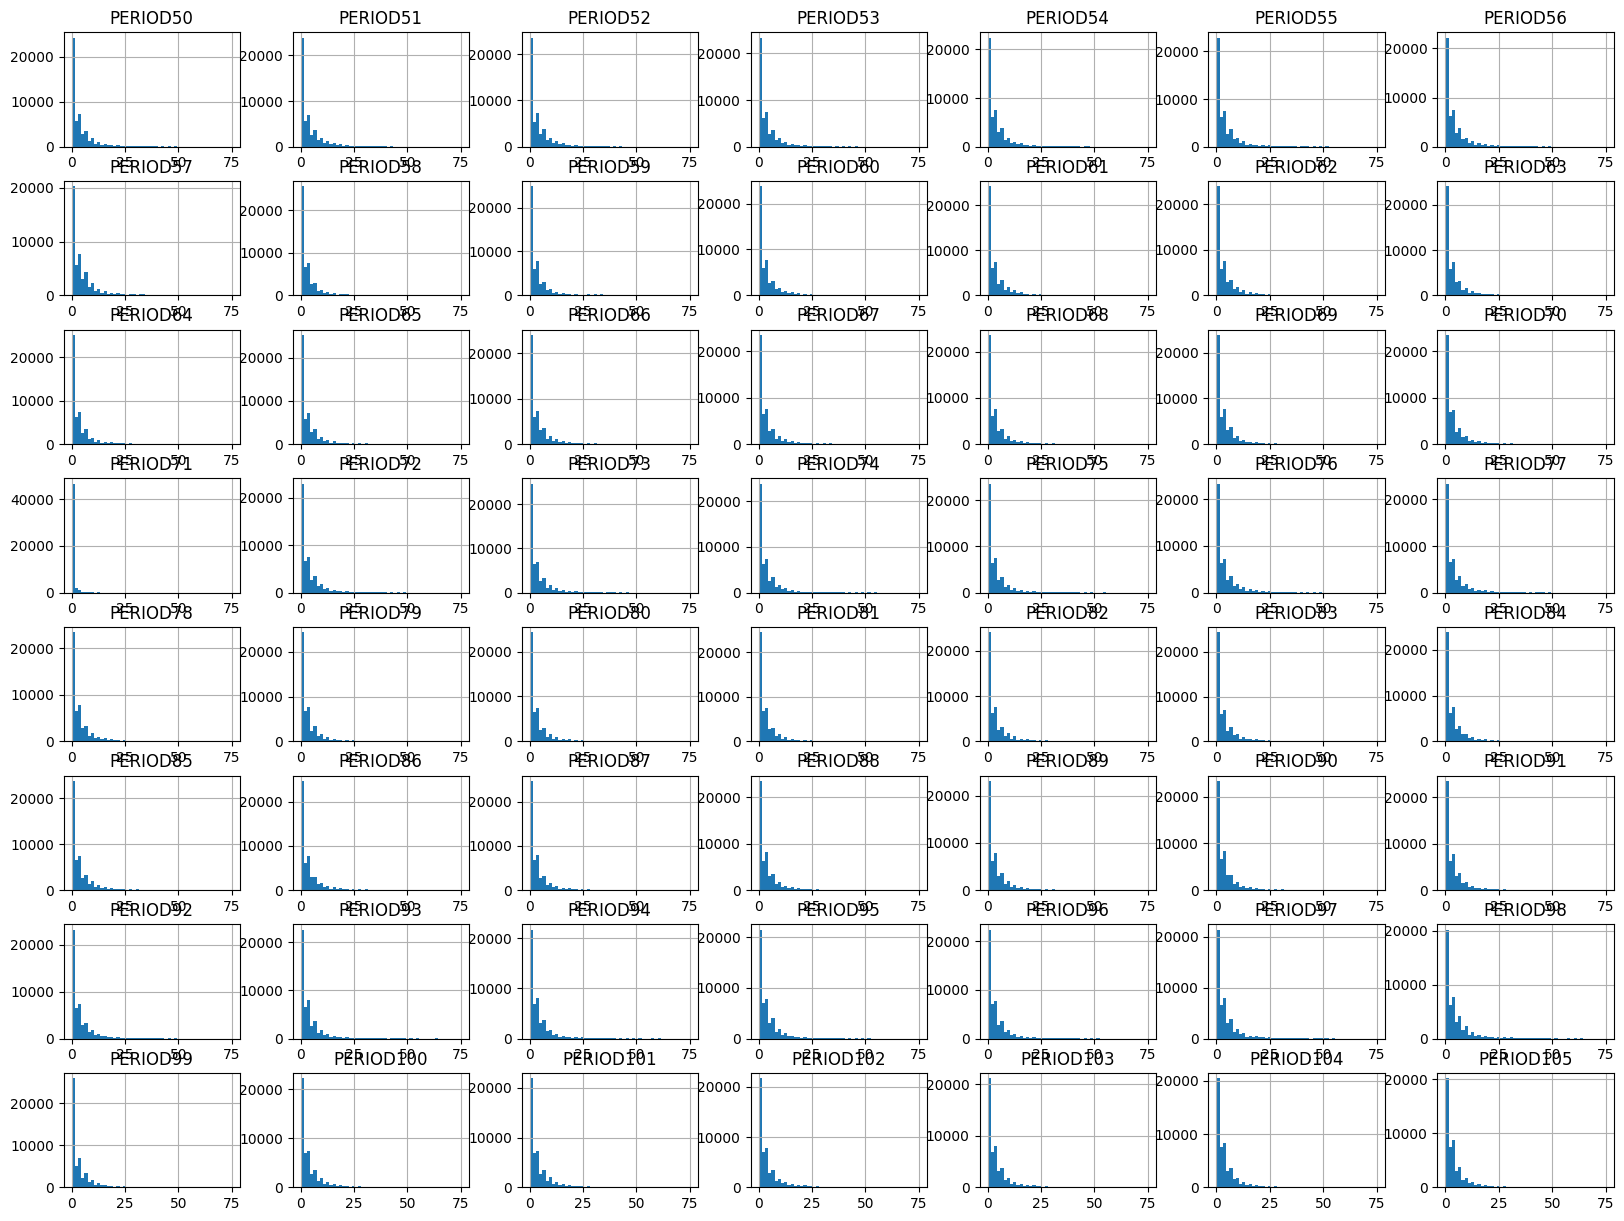

In [46]:
# Look at the distribution of the Period features.

df.loc[:, 'PERIOD50':'PERIOD105'].hist(bins=50, range=[0, 75], figsize=(20,15))
plt.show()

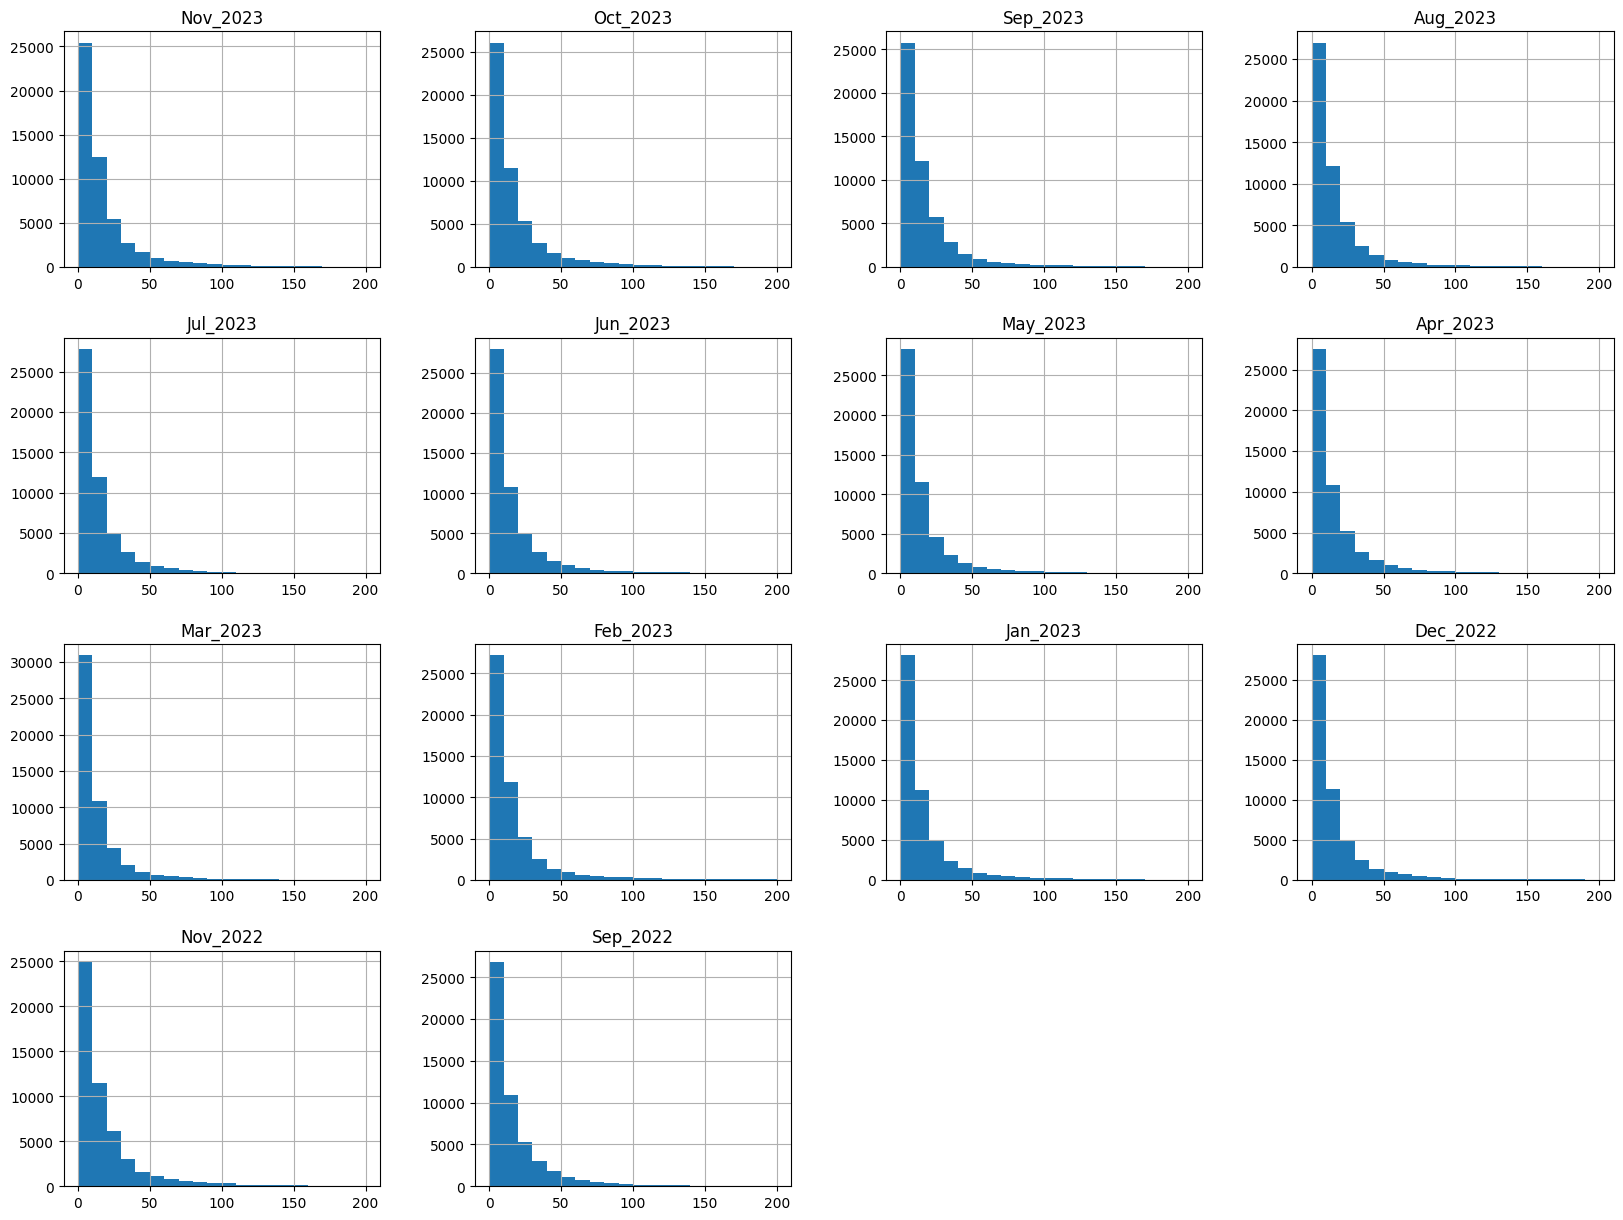

In [47]:
# Look at the distribution of the Month features.

df.loc[:, 'Nov_2023':'Sep_2022'].hist(bins=20, range=[0, 200], figsize=(20,15))
plt.show()

For both each period (week) and month, data skews right indicating that most sales per week or month are smaller amounts.

In [48]:
grouped_df = df.groupby('City').agg({
    'Total_Sales': 'sum',
    'Nov_2023': 'sum',
    'Oct_2023': 'sum',
    'Sep_2023': 'sum',
    'Aug_2023': 'sum',
    'Jul_2023': 'sum',
    'Jun_2023': 'sum',
    'May_2023': 'sum',
    'Apr_2023': 'sum',
    'Mar_2023': 'sum',
    'Feb_2023': 'sum',
    'Jan_2023': 'sum',
    'Dec_2022': 'sum',
    'Nov_2022': 'sum',
    'Sep_2022': 'sum'
}).reset_index()

# Rename the columns if needed
grouped_df.columns = ['City', 'Total_Sales', 'Nov_2023', 'Oct_2023', 'Sep_2023', 'Aug_2023', 'Jul_2023',
                      'Jun_2023', 'May_2023', 'Apr_2023', 'Mar_2023', 'Feb_2023', 'Jan_2023',
                      'Dec_2022', 'Nov_2022', 'Sep_2022']

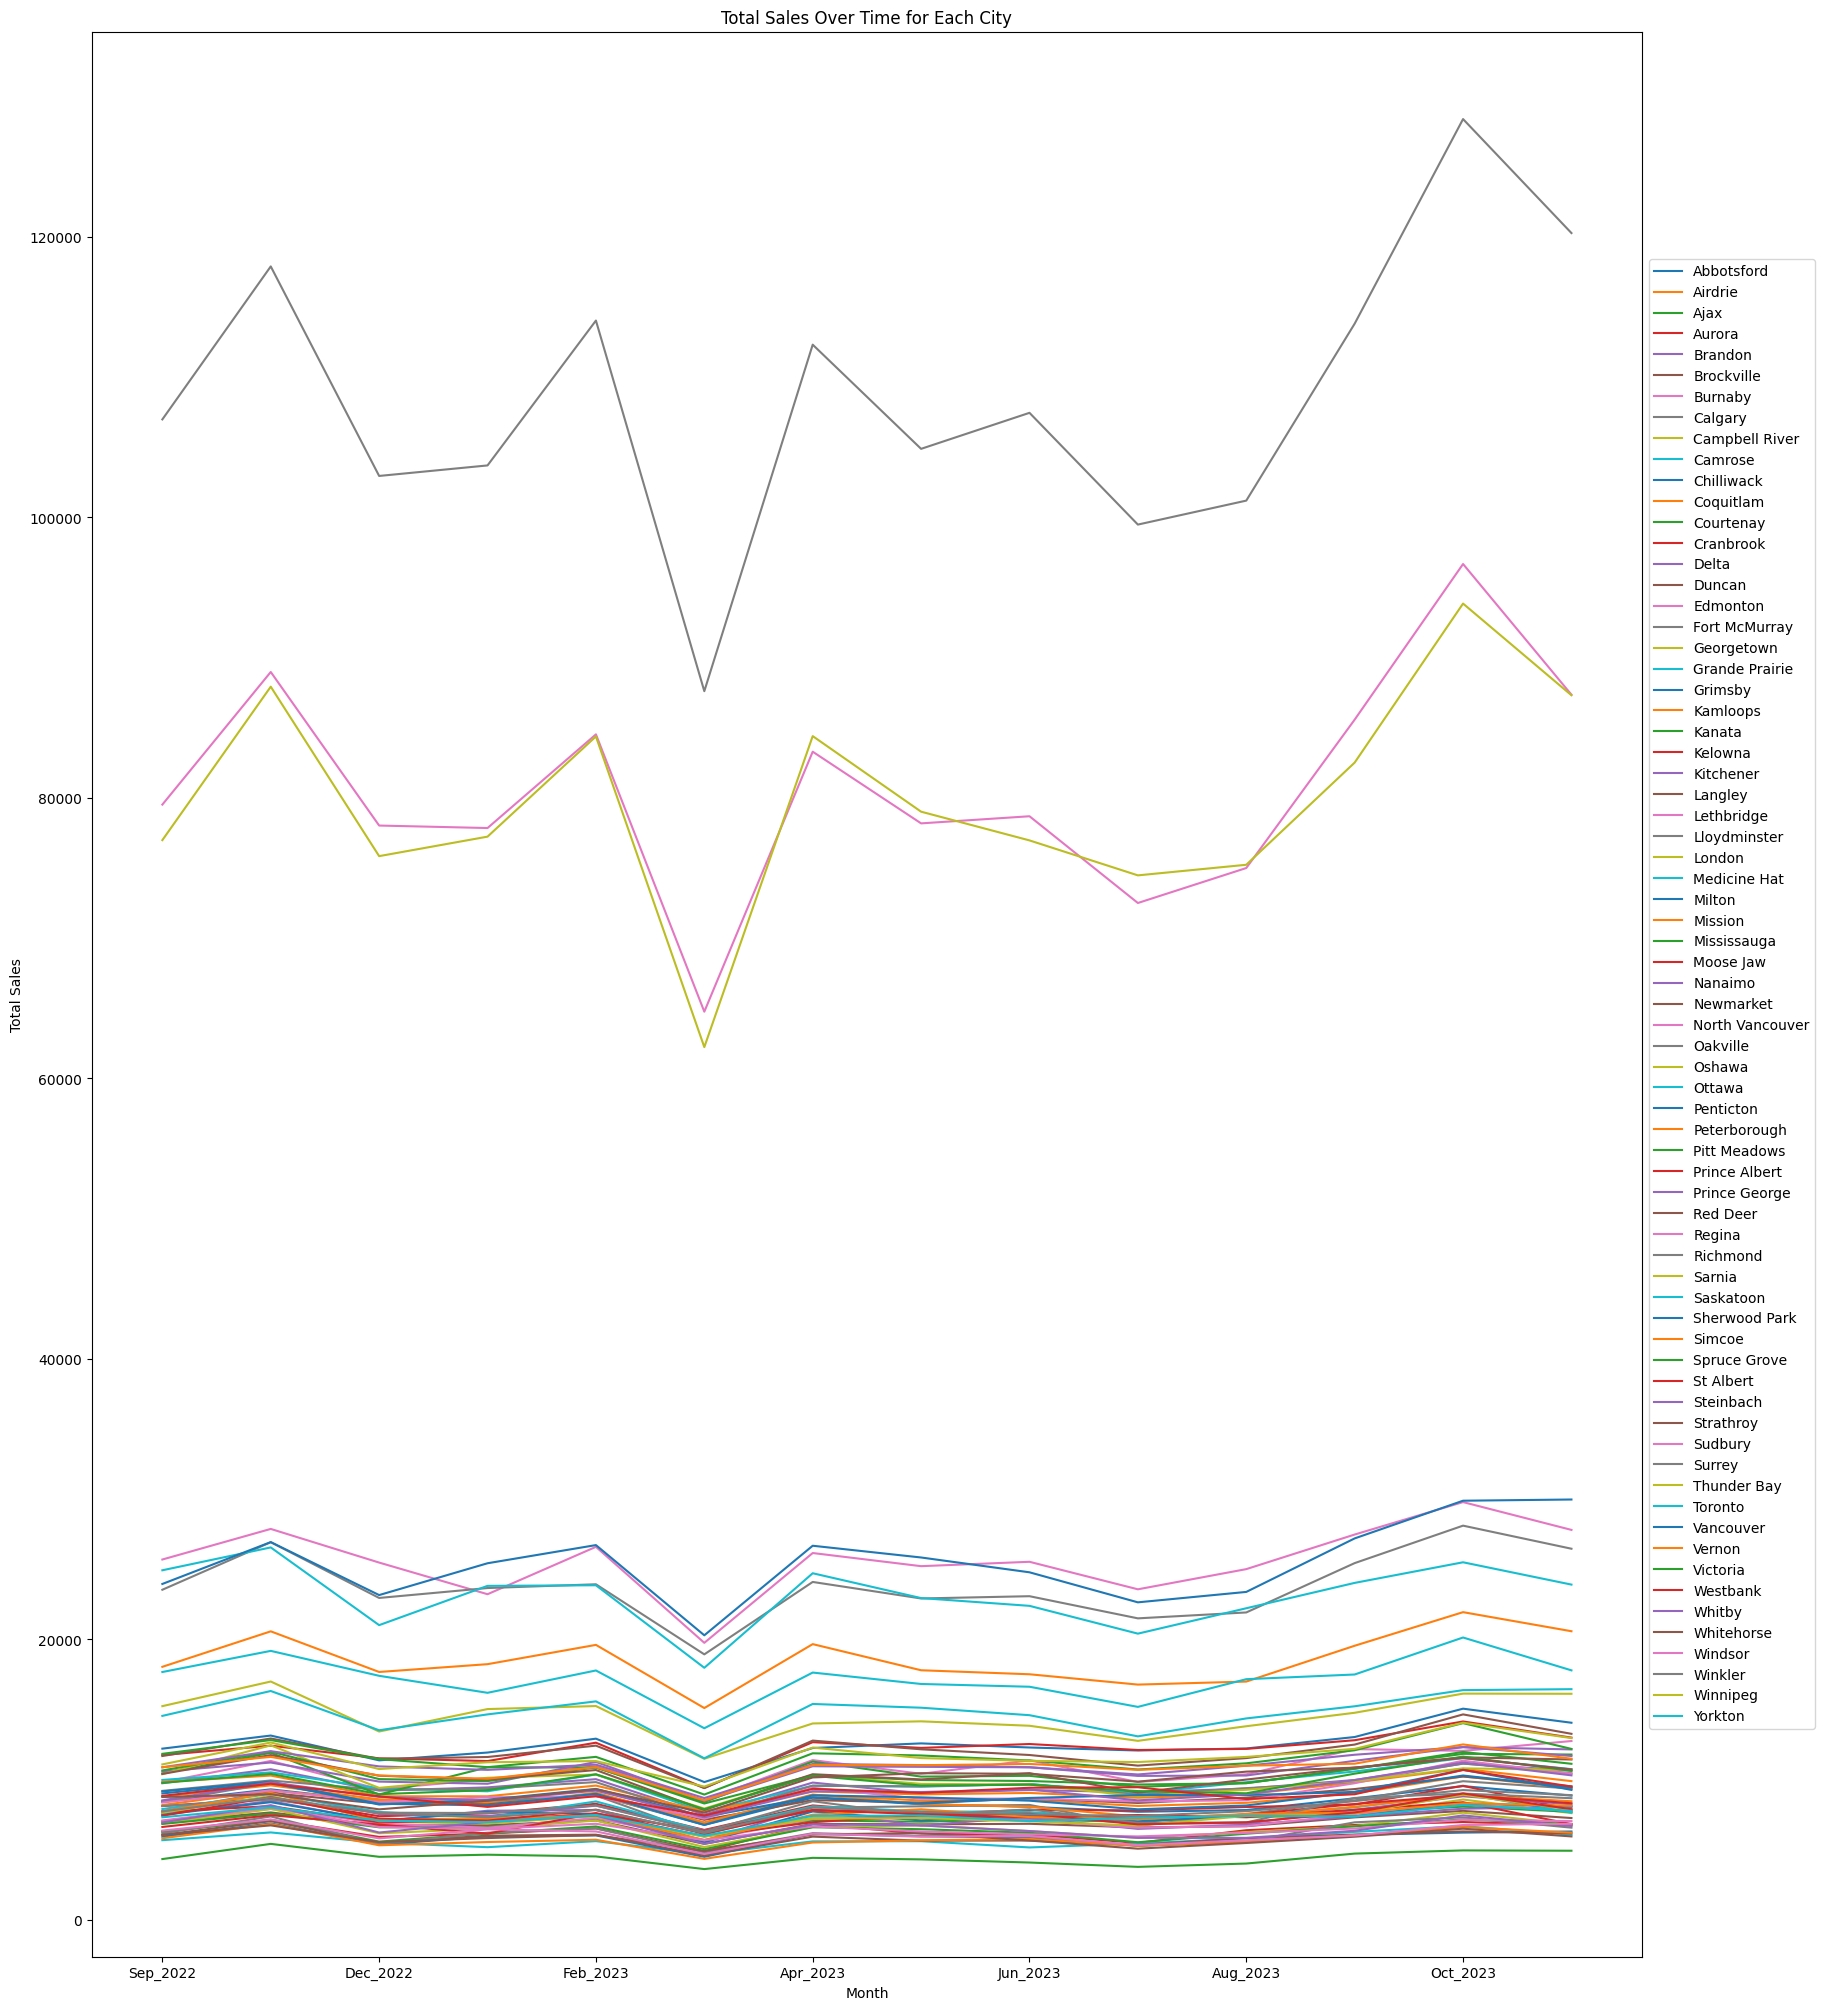

In [51]:
grouped_df.set_index('City')[['Sep_2022', 'Nov_2022', 'Dec_2022',
    'Jan_2023', 'Feb_2023', 'Mar_2023',
    'Apr_2023', 'May_2023', 'Jun_2023',
    'Jul_2023', 'Aug_2023', 'Sep_2023',
    'Oct_2023', 'Nov_2023']].T.plot(legend=True,figsize=(20, 25))
plt.title('Total Sales Over Time for Each City')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.show()

In [52]:
# Create a list of all Period Columns.

dfp = df.loc[:, "PERIOD50":"PERIOD105"]
dfp_cols = list(dfp.columns.values)

dfm = df.loc[:, "Nov_2023":"Sep_2022"]
dfm_cols = list(dfm.columns.values)

#### Correlation: Continuous Features

(Months and Weekly Periods)

In [53]:
# Create correlation functions.

def create_correlation(target, features):
    my_matrix = df.loc[:, [target] + features].corr(method='pearson')
    return my_matrix[target].sort_values(ascending=False)

def print_correlation_plot(target, features):
    sns.pairplot(data=df.loc[:, [target] + features])
    plt.show()

In [54]:
# Run some correlations on the Period set of features and the Total_Sales.
# There appears to be a high correlation between some of these Periods and
# the Total_Sales.

feature_list = dfp_cols

create_correlation("Total_Sales", feature_list)

Total_Sales    1.000000
PERIOD82       0.877485
PERIOD83       0.871946
PERIOD81       0.868674
PERIOD102      0.867255
PERIOD84       0.861714
PERIOD87       0.858796
PERIOD97       0.858362
PERIOD74       0.856492
PERIOD64       0.856452
PERIOD63       0.852950
PERIOD66       0.852818
PERIOD76       0.849287
PERIOD92       0.846979
PERIOD67       0.846128
PERIOD53       0.845066
PERIOD105      0.843502
PERIOD85       0.843393
PERIOD98       0.839268
PERIOD80       0.838834
PERIOD86       0.835526
PERIOD62       0.835283
PERIOD56       0.835161
PERIOD96       0.834069
PERIOD51       0.833799
PERIOD78       0.833344
PERIOD54       0.831854
PERIOD70       0.830204
PERIOD103      0.830080
PERIOD50       0.826489
PERIOD88       0.826168
PERIOD104      0.825581
PERIOD94       0.822584
PERIOD75       0.821012
PERIOD91       0.820201
PERIOD60       0.819508
PERIOD90       0.817991
PERIOD55       0.817487
PERIOD65       0.812276
PERIOD52       0.809204
PERIOD69       0.807647
PERIOD89       0

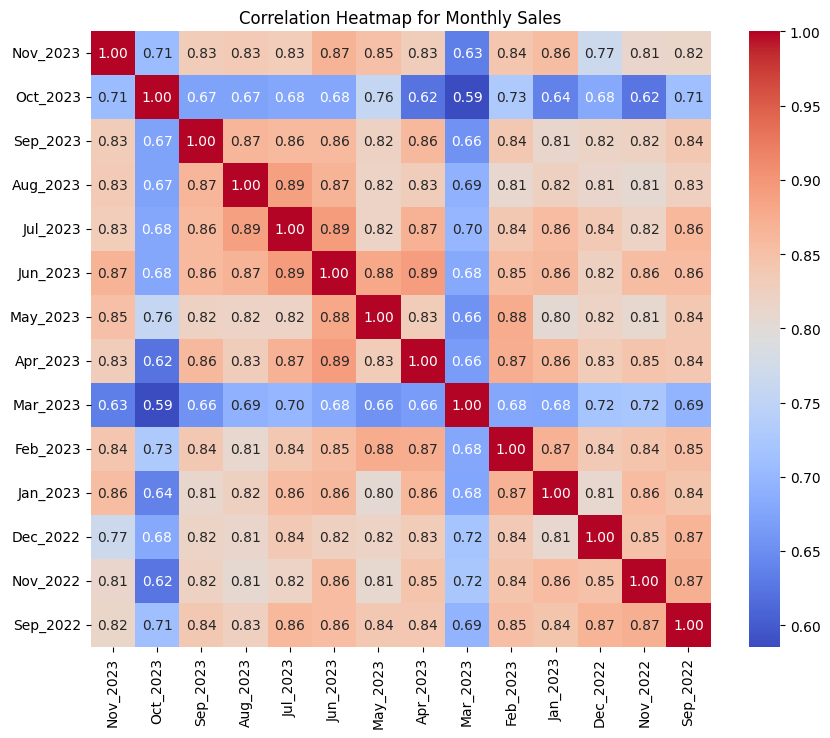

In [55]:
#correlation between different months' sales.
corr_matrix = df[['Nov_2023', 'Oct_2023', 'Sep_2023', 'Aug_2023', 'Jul_2023',
                  'Jun_2023', 'May_2023', 'Apr_2023', 'Mar_2023', 'Feb_2023', 'Jan_2023',
                  'Dec_2022', 'Nov_2022', 'Sep_2022']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap for Monthly Sales')
plt.show()

In [56]:
# Run some correlations on the Month set of features and the Total_Sales.
# There appears to be a high correlation between some of these Periods and
# the Total_Sales.

month_feature_list = dfm_cols

create_correlation("Total_Sales", month_feature_list)

Total_Sales    1.000000
Jun_2023       0.938971
Feb_2023       0.934182
Jul_2023       0.928136
Sep_2022       0.927744
May_2023       0.922072
Apr_2023       0.921547
Jan_2023       0.914587
Sep_2023       0.914483
Aug_2023       0.912174
Nov_2023       0.911629
Nov_2022       0.911034
Dec_2022       0.907198
Oct_2023       0.791674
Mar_2023       0.767568
Name: Total_Sales, dtype: float64

With high correlation between sales in certain months, could those be used to predict total sales for the year?

In [57]:
# Display the period feature list in a correlation plot (named feature_list).

#print_correlation_plot("Total_Sales", feature_list)

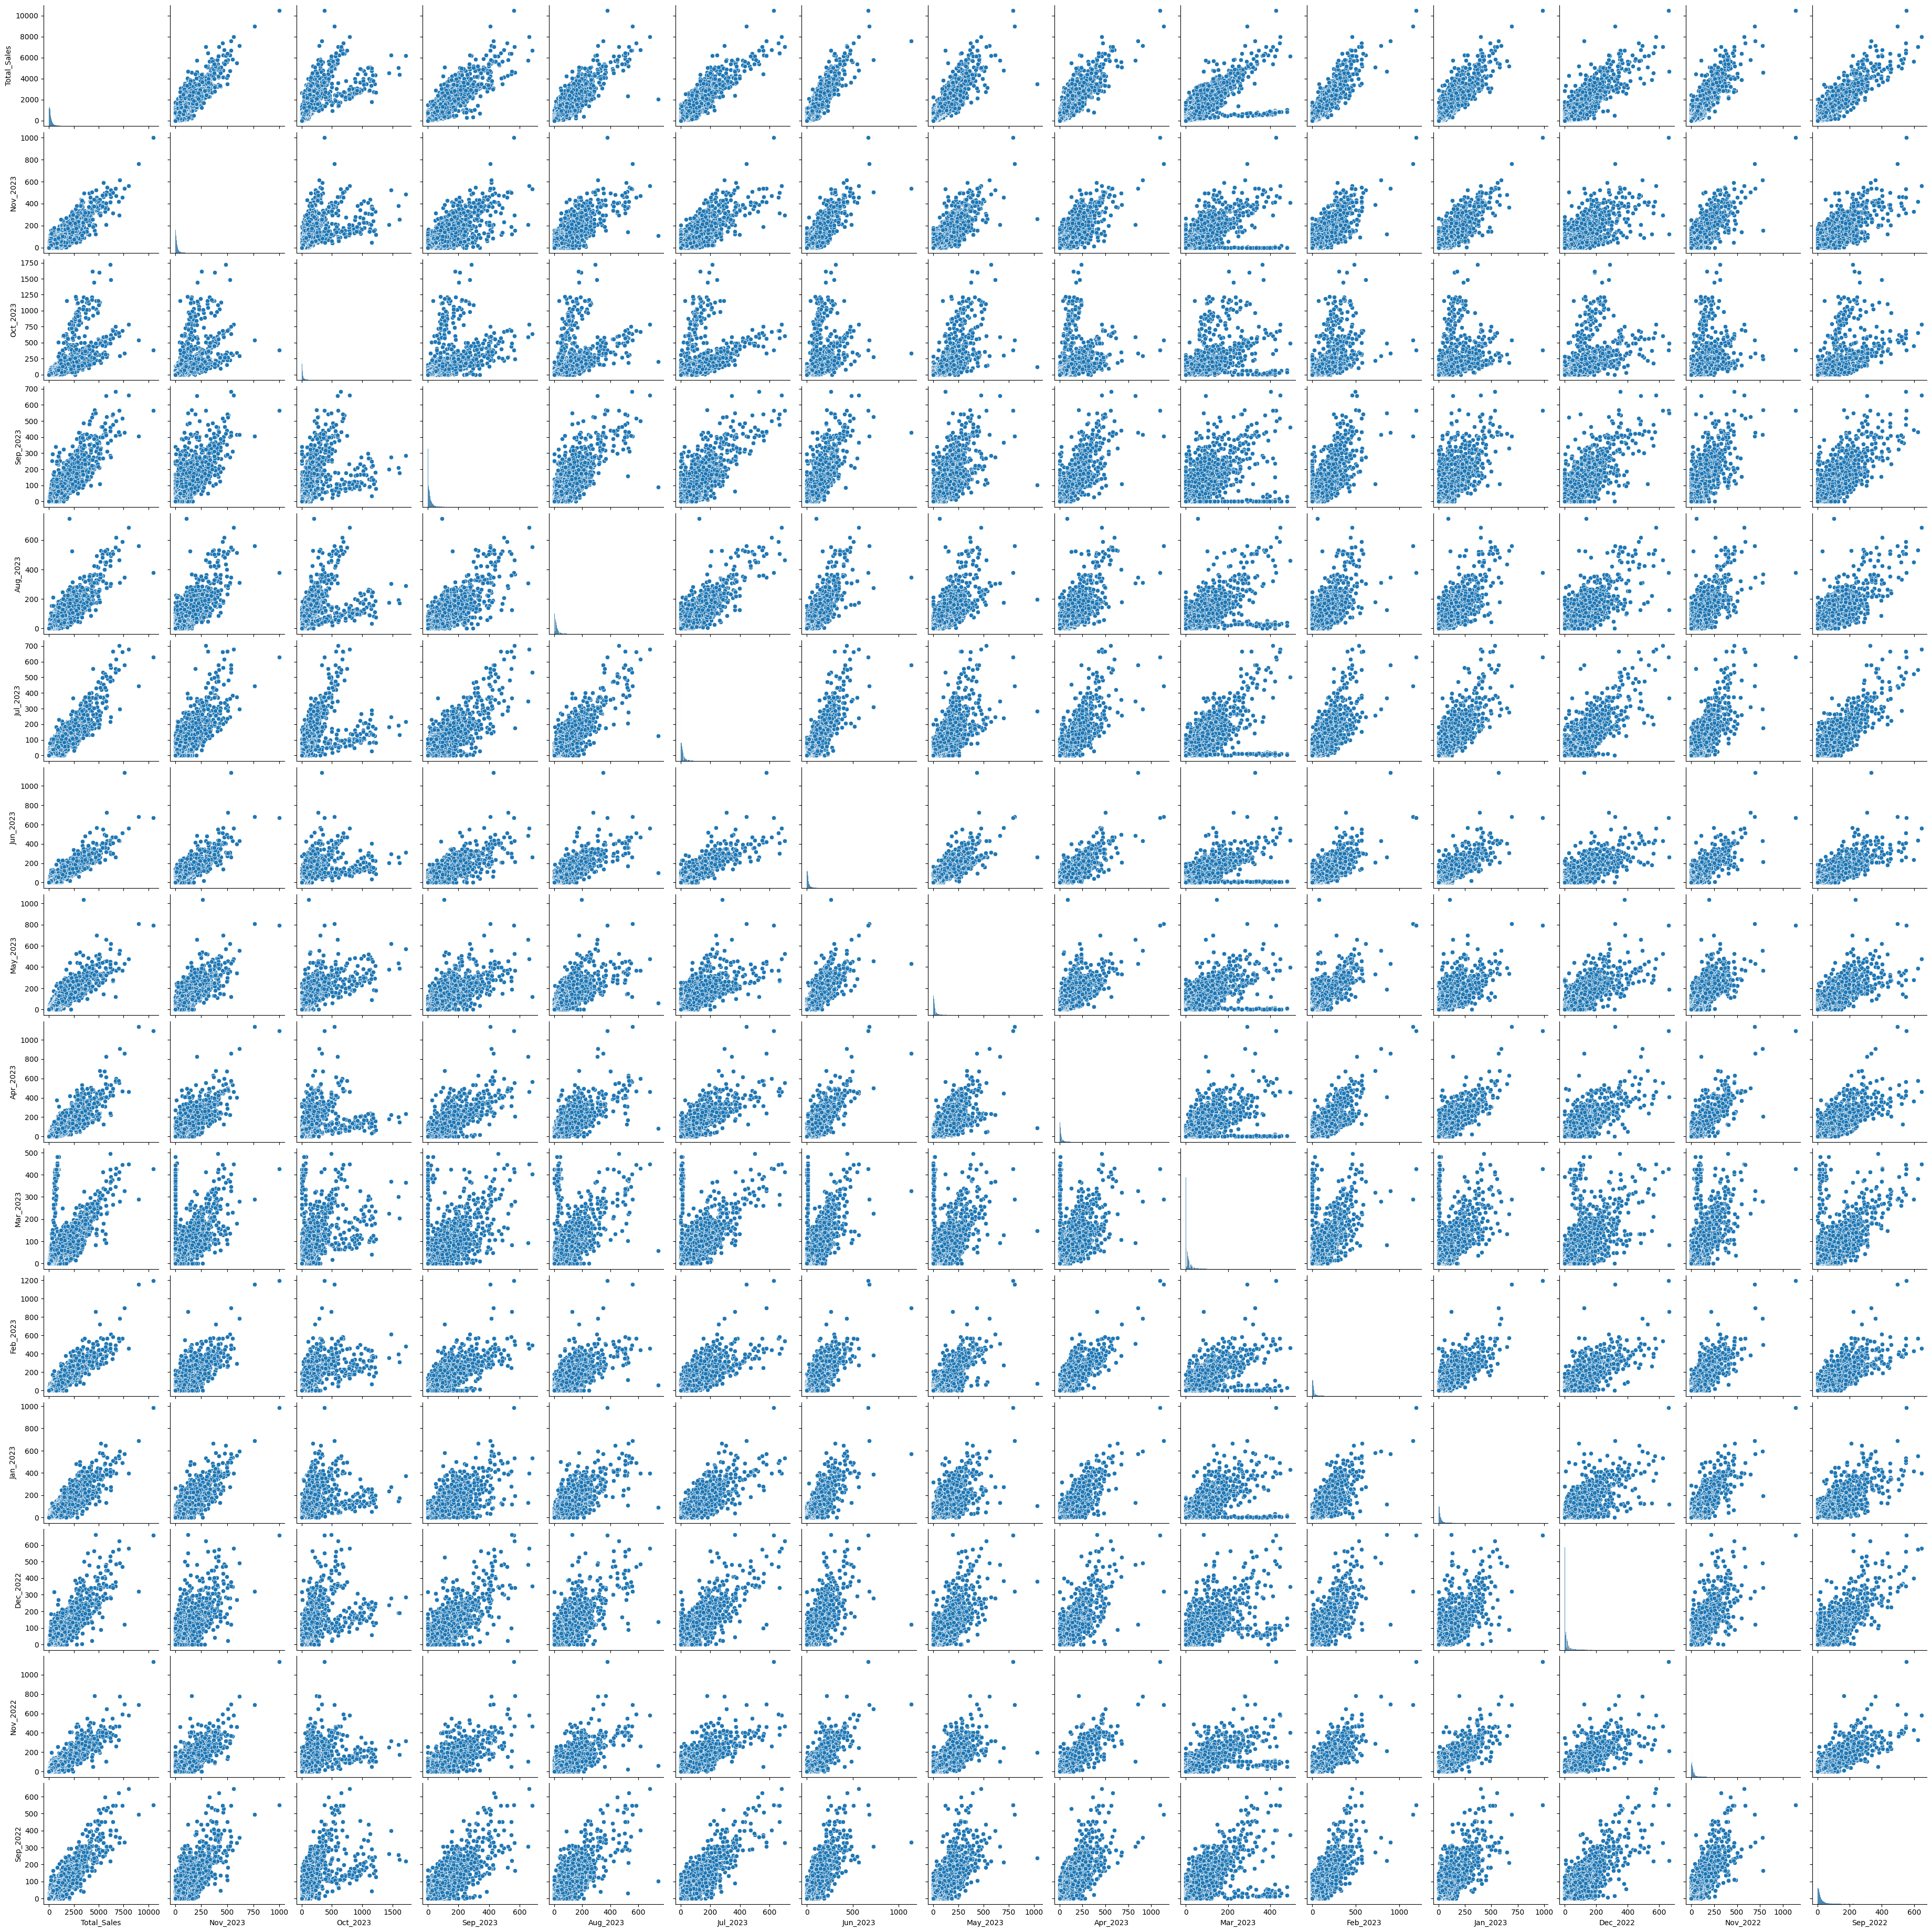

In [58]:
# Display the month feature list in a correlation plot.

print_correlation_plot("Total_Sales", month_feature_list)

#### Correlation: Categorical Features

In [59]:
# Create a box plot function using the function in the course notes.

def create_box_plot(df_bp, x_axis, y_axis):
    plt.figure(figsize=(5,5))
    sns.boxplot(x=x_axis, y=y_axis, data=df_bp)

    if len(df[x_axis].unique()) > 4:
        plt.xticks(rotation=45)

    plt.show()

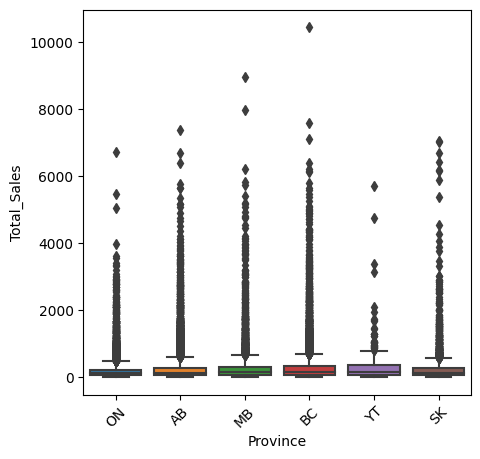

In [60]:
# Boxplot Province vs Total_Sales.

create_box_plot(df, 'Province', 'Total_Sales')

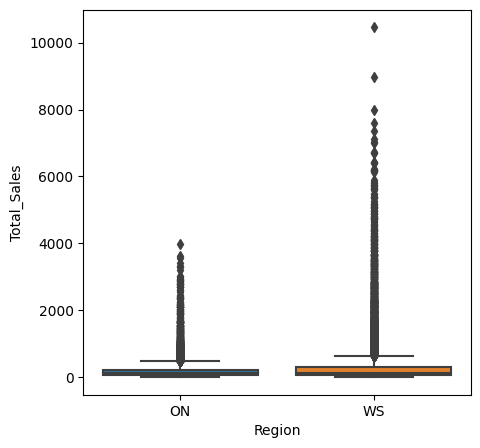

In [61]:
# Boxplot Region vs Total_Sales.

create_box_plot(df, 'Region', 'Total_Sales')

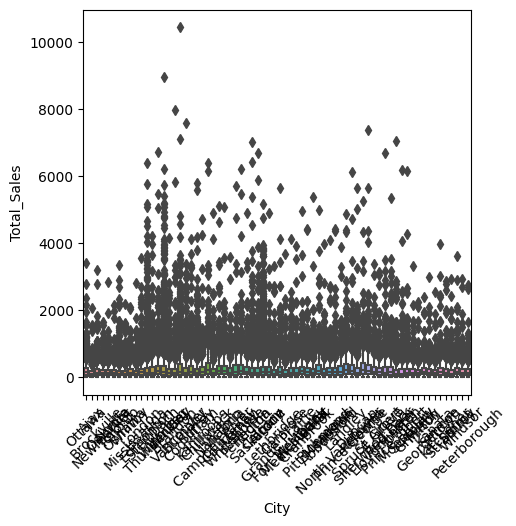

In [62]:
# Boxplot Region vs Total_Sales.

create_box_plot(df, 'City', 'Total_Sales')

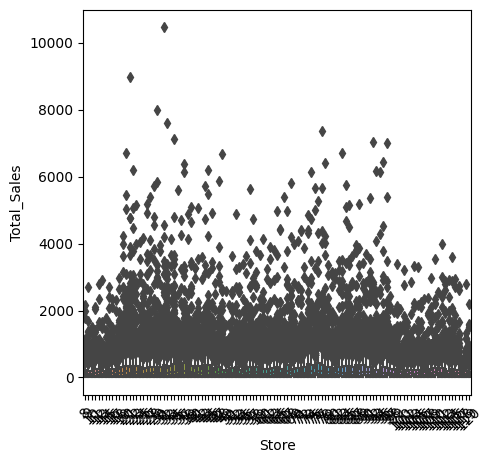

In [63]:
# Boxplot Region vs Total_Sales.

create_box_plot(df, 'Store', 'Total_Sales')

Even though the above two box plots are difficult to read, it does appear that most Cities and Stores are still within the standard statistical ranges of each other.

In [64]:
# There appears to be a number of outliers.  Take a look at what may be
# skewing the numbers.

df_outlier = df[df['Total_Sales'] > 5000]
df_outlier['Coffee_Product'].value_counts()

MH EZO TIN ORIGINAL ROAST          26
NESCAFE COFFEE INSTNT RICH BLND     9
PC COFFEE WEST COAST DARK           6
FOLGERS CLSC RST GRD COFFEE         5
NABOB TRAD COFFEE FINE GRND CP      1
Name: Coffee_Product, dtype: int64

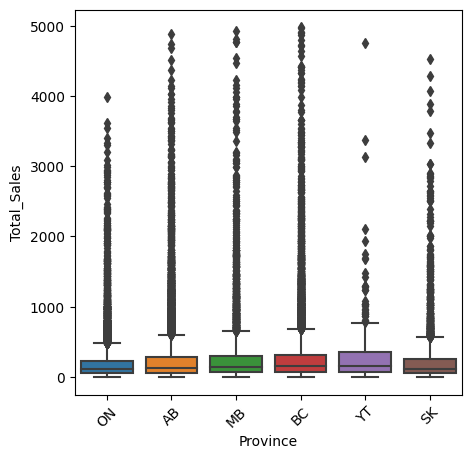

In [65]:
# Create another Boxplot Province vs Total_Sales without the outliers.

df_sans_outlier = df[df['Total_Sales'] < 5000]
create_box_plot(df_sans_outlier, 'Province', 'Total_Sales')

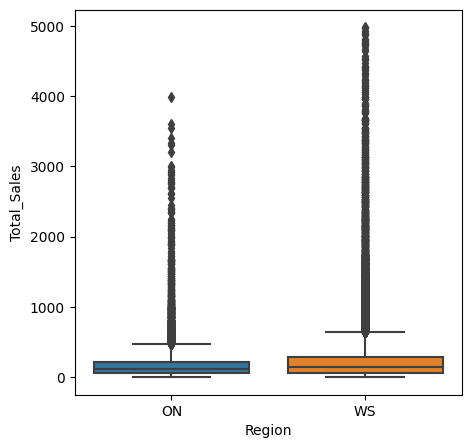

In [66]:
# Create another Boxplot of Region vs Total_Sales without the outliers.

create_box_plot(df_sans_outlier, 'Region', 'Total_Sales')

Looking at the Box Plots, there doesn't appear to be a strong correlation between Total Sales and the Province even when the outliers are removed.

However, there appears to be a correlation between Periods and the Total_Sales.

Machine Learning Model Preparation

In [67]:
# Define the model's categorical and numerical features.

categorical_features = [ "Coffee_Product", "SOURCE", "City", "Province", "Region", "Size"]

# For the numerical features, use the sales by months features (dfm_cols).
# To use the sales by weekly period features, use dfp_cols.

#numerical_features = dfp_cols
numerical_features = dfm_cols

In [68]:
# Categorical

# Use One Hot Encoding on the categorical features.

cat_ohe_step = ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
cat_steps = [cat_ohe_step]
cat_pipe = Pipeline(cat_steps)

cat_transformers = [('cat', cat_pipe, categorical_features)]

# Numerical

# To ensure those features with large values don't have more influence than those numerical
# features that have smaller values.

num_scl_step = ('scl', MinMaxScaler(feature_range=(0,1)))
num_steps = [num_scl_step]
num_pipe = Pipeline(num_steps)
num_transformers = [('num', num_pipe, numerical_features)]

In [69]:
# create_transformations

def create_transformations(include_categorical=True,
                           include_numerical=True):

    included_transformers = cat_transformers + num_transformers
    included_features = categorical_features + numerical_features

    if (include_categorical == False):
      included_transformers = num_transformers
      included_features = numerical_features

    if (include_numerical == False):
      included_transformers = cat_transformers
      included_features = categorical_features

    # Create the Column Transformer with the categorical and numerical transformers.

    ct = ColumnTransformer(transformers=included_transformers)

    ct.fit(df[included_features])

    # Set the features, X.

    X = ct.transform(df[included_features])

    # Set the target, y.

    y = df[['Total_Sales']].values

    return X, y


# generate_train_test_data

def generate_train_test_data(X, y):

    # Implement the Train-Test Split using our X and y variables.  Aim for a 20-30% test size.

    # removed: stratify=y

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

    print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

    return X_train, X_test, y_train, y_test


Machine Learning Models

Unsupervised Learning: Clustering for data anomaly detection

In [70]:
# invoke_kmeans

def invoke_kmeans(X_in, num_clusters, num_runs=10, num_iterations=300):

    # For deterministic k-means clustering, set the random_num
    random_num = 0

    # Invoke the KMeans function and fit the X data.
    kmeans = KMeans(init="random", n_clusters=num_clusters, n_init=num_runs, max_iter=num_iterations,
                    random_state=random_num)
    kmeans.fit(X_in)

    # Return the object.
    return kmeans


# print_kmeans_data

def print_kmeans_data(kmeans):
    print ("Inertia: ", kmeans.inertia_)
    print ("n_iter:  ", kmeans.n_iter_)


# create_x_and_y_parallel_array

def create_x_and_y_parallel_array(data_in):

    # Create blank parallel arrays
    x_data = []
    y_data = []

    # Iterate over the 2d array ([x, y]) and add the x and y values
    # to their respective parallel arrays.
    for j in data_in:
        x_data.append(j[0])
        y_data.append(j[1])

    return x_data, y_data


# plot_line_graph

def plot_line_graph(x_data, y_data, title="No Title", x_label="No X", y_label="No Y"):

    # Create the figure.
    plt.figure(dpi=100)

    # Set line graph details.
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)

    # Create arrays from the x_data and y_data lists.
    x = np.array(x_data)
    y = np.array(y_data)

    # Plot the arrays.
    plt.plot(x,y)

    # Display the plot.
    plt.show()

In [71]:
def create_clusters(X):

    my_data = []

    # Invoke kmeans clustering starting from 2 clusters to 200 clusters and calculate the
    # inertia (sum of total distances).

    # Note: range 2, 10 takes 5 minutes;
    #       range 2, 40 takes ~20 minutes

    for i in range(2, 10):

        # Invoke kmeans and append the inertia to the array.
        print ("Creating cluster", i)
        my_kmeans = invoke_kmeans(X, i)

        print ("Done cluster", i)
        my_data.append([i, my_kmeans.inertia_])

    # Print a couple of data points.

    print (my_data[0], my_data[1])

    return my_data



def print_elbow_curve(my_data):

    # Create the x and y parallel arrays.

    x_data, y_data = create_x_and_y_parallel_array(my_data)

    # Plot the Inertia line graph.

    plot_line_graph(x_data, y_data, "Inertia Elbow Graph", "Number of Clusters", "Inertia Value")



In [72]:
# calculate_silhouette_score

def calculate_silhouette_score(X_in, num_clusters):

    # Invoke the KMeans model.
    kmeans_model = invoke_kmeans(X_in, num_clusters)
    labels = kmeans_model.labels_

    # Return the Silhouette score.
    return metrics.silhouette_score(X_in, labels, metric='euclidean')


# calculate_silhouette_scores_for_clusters

def calculate_silhouette_scores_for_clusters(X, num_clusters):

    s_data = []

    # Iterate over 8 clusters to help determine optimal number of clusters.

    for i in range (2, num_clusters):

        # Calculate the Silhouette score and append it to the array.

        print ("Processing Cluster", i)
        silhouette_score = calculate_silhouette_score(X, i)
        print ("Completed Cluster ", i)
        s_data.append([i, silhouette_score])

    # Print out the scores for each cluster.

    print ("Cluster\t\tSilhouette Score")
    print ("-------\t\t----------------")

    for i in s_data:
        print(i[0], "\t\t", i[1])


# build_clusters

def build_clusters(X, num_clusters):

    # Make a copy of X to keep X intact.

    my_X_copy = X.copy()

    # Use 4 as the number of clusters.

    my_kmeans = invoke_kmeans(X, num_clusters)

    cluster_labels = my_kmeans.labels_

    cluster_dict = {}
    cluster_index = 0

    # Iterate over the cluster labels and build the cluster dictionary of associated arrays
    # that will contain the individual records.  These records are stored in the master X.

    for i in cluster_labels:

        # If the cluster label dictionary key has not been created yet, create it.

        if (i not in cluster_dict.keys()):
            cluster_array = []
        else:
            # Cluster label dictionary key has been created.  Therefore, get the array.

            cluster_array = cluster_dict.get(i)

        # Append the record to the cluster and set it back to the dictionary.

        cluster_array.append(my_X_copy[cluster_index])
        cluster_dict[i] = cluster_array

        # Increment the cluster index.

        cluster_index += 1

    # Print the cluster dictionary keys to ensure that all the clusters were created.
    print (cluster_dict.keys())

    return cluster_dict


# plot_cluster_distribution

def plot_cluster_distribution(cluster_dict):

    cluster_records = []
    clusters = list(cluster_dict.keys())

    for i in cluster_dict.keys():
        cluster_records.append((len(cluster_dict[i])))

    fig = plt.figure(figsize = (10, 5))

    # Create the bar chart.

    plt.bar(clusters, cluster_records, color ='maroon', width = 0.4)

    plt.xlabel("Cluster")
    plt.ylabel("Number of Records")
    plt.title("Distribution of Records in Clusters")
    plt.show()


Given that the clusters are generally-speaking similar, there doesn't appear to be any particular anomalies to the data.

Supervised Learning to test performance of predictive models.  As target, Total_Sales, is a continuous integer, use Regression models.

In [73]:
# For Regression: Calculate RMSE method from the course documentation.

def rmse(predictions, targets):
    return np.sqrt(np.mean((predictions - targets)**2))

# Display results for model from the course documentation.

def display_results(model, X, y):
    print("RMSE:", rmse(model.predict(X), y))
    print("Predicted Sales 1-5:", model.predict(X_test[0:5]))
    print("Actual Sales 1-5:   ", y_test[0:5, 0])


# Display the scores from the course documentation.

def display_scores(scores):
    print("Scores:", np.sqrt(-scores))
    print("Mean:", np.sqrt(-scores).mean())
    print("Standard deviation:", np.sqrt(-scores).std())

In [74]:

def calculate_HistGradientBoostingRegressor(X_train, X_test, y_train, y_test):

    # Create the HistGradientBoostingRegressor and fit the training data.

    print("\nHistGradientBoostingRegressor")
    print("-----------------------------")

    hgr = HistGradientBoostingRegressor()
    hgr.fit(X_train, np.ravel(y_train))

    y_pred = hgr.predict(X_test)

    print("Predicted Sales 1-5:", hgr.predict(X_test[0:5]))
    print("Actual Sales 1-5:   ", y_test[0:5, 0])
    print("RMSE: ", rmse(y_pred, y_test))


In [75]:

def calculate_RandomForestRegressor(X_train, X_test, y_train, y_test):

    # Create the RandomForestRegressor and fit the training data.

    print("\nRandomForestRegressor")
    print("---------------------")

    rfr = RandomForestRegressor(max_depth=2, random_state=0)
    rfr.fit(X_train, np.ravel(y_train))

    y_pred = rfr.predict(X_test)

    print("Predicted Sales 1-5:", rfr.predict(X_test[0:5]))
    print("Actual Sales 1-5:   ", y_test[0:5, 0])
    print("RMSE: ", rmse(y_pred, y_test))

In [76]:
def calculate_LinearRegression(X_train, X_test, y_train, y_test):

    # Create the LinearRegression and fit the training data.

    print("\nLinearRegression")
    print("----------------")

    lr = LinearRegression()
    lr.fit(X_train, np.ravel(y_train))

    y_pred = lr.predict(X_test)

    print("Predicted Sales 1-5:", lr.predict(X_test[0:5]))
    print("Actual Sales 1-5:   ", y_test[0:5, 0])
    print("RMSE: ", rmse(y_pred, y_test))

Categorical Data ONLY

In [77]:
# Create the Transformations for Categorical Data only.

X, y = create_transformations(True, False)

# Train the model.

X_train, X_test, y_train, y_test = generate_train_test_data(X, y)

(41603, 512) (10401, 512) (41603, 1) (10401, 1)


Creating cluster 2
Done cluster 2
Creating cluster 3
Done cluster 3
Creating cluster 4
Done cluster 4
Creating cluster 5
Done cluster 5
Creating cluster 6
Done cluster 6
Creating cluster 7
Done cluster 7
Creating cluster 8
Done cluster 8
Creating cluster 9
Done cluster 9
[2, 145265.28457869953] [3, 129084.2291707857]


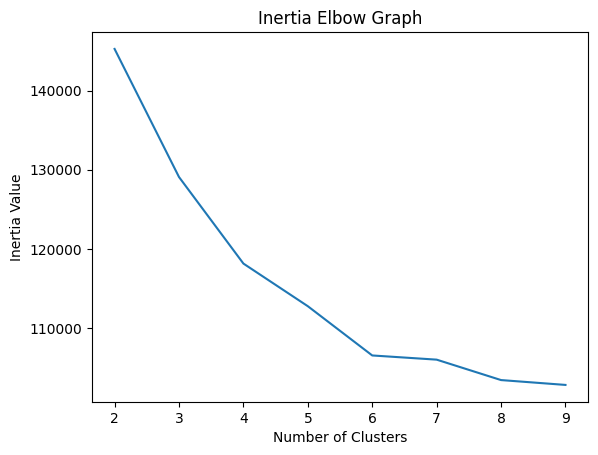

Processing Cluster 2
Completed Cluster  2
Processing Cluster 3
Completed Cluster  3
Cluster		Silhouette Score
-------		----------------
2 		 0.20259844224434448
3 		 0.18903453825949548


In [78]:
# Create the clusters.

my_data = create_clusters(X)

# Print the Elbow curve.

print_elbow_curve(my_data)

# Verify by calculating the silhouette scores.

calculate_silhouette_scores_for_clusters(X, 4)

Doesn't appear to be strong clustering of data based on silhouette scores.  The highest ~.20.

dict_keys([1, 0])


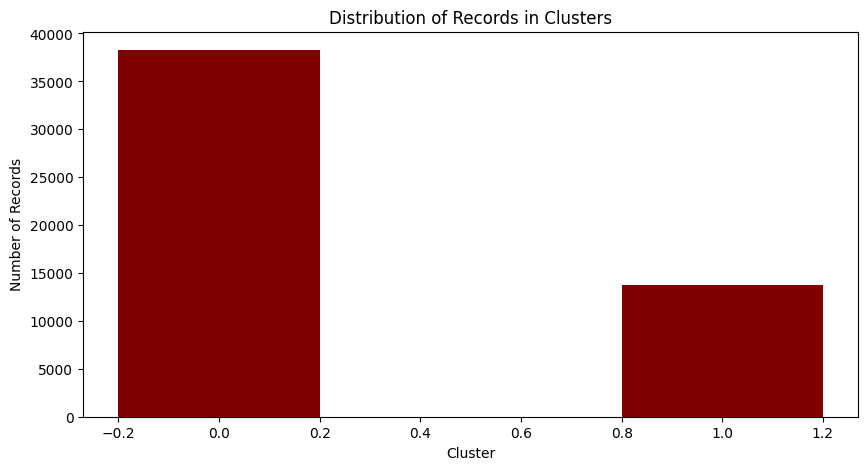

In [79]:
# Build the clusters based on the number of clusters above.

cluster_dict = build_clusters(X, 2)

# Plot the cluster distribution.

plot_cluster_distribution(cluster_dict)

In [80]:
# Run the data through the different Regression ML models to
# evaluate performance.

calculate_HistGradientBoostingRegressor(X_train, X_test, y_train, y_test)
calculate_RandomForestRegressor(X_train, X_test, y_train, y_test)
calculate_LinearRegression(X_train, X_test, y_train, y_test)


HistGradientBoostingRegressor
-----------------------------
Predicted Sales 1-5: [ 92.91765877 351.50762991 271.55753911 138.66078157 121.05200747]
Actual Sales 1-5:    [153.         286.         223.06671241 187.          80.        ]
RMSE:  539.8441782087214

RandomForestRegressor
---------------------
Predicted Sales 1-5: [235.0755738 235.0755738 235.0755738 235.0755738 235.0755738]
Actual Sales 1-5:    [153.         286.         223.06671241 187.          80.        ]
RMSE:  456.89025925440905

LinearRegression
----------------
Predicted Sales 1-5: [130.1875 424.9375 305.6875  91.4375 132.5625]
Actual Sales 1-5:    [153.         286.         223.06671241 187.          80.        ]
RMSE:  908488933542.8225


In [81]:
# The predicted vs actuals don't really line up - the best is LinearRegresssion


In [82]:
# Now, put it through cross validation to see if the scores are better.

#enr = RandomForestRegressor()
#enr = LinearRegression()
enr = HistGradientBoostingRegressor()
scores = cross_val_score(enr, X, np.ravel(y), cv=5, scoring='neg_mean_squared_error')
display_scores(scores)

Scores: [215.93397409 279.22023384 206.95261125 247.36367301 178.43700254]
Mean: 225.58149894499647
Standard deviation: 34.68224537646629


##Hyperparameters

Conduct a search for the best hyperparameters on the RandomForestRegressor as it didn't appear to do as well as the others.

In [83]:
# Hyperparameter Search for RandomForestRegressor.

estimator = RandomForestRegressor()
param_grid = {
            "n_estimators"      : [4, 5, 10],  # Add all 3 estimators
            "max_features"      : ["sqrt", "log2"],
            "min_samples_split" : [2,4,8],
            "bootstrap": [True, False],
            }

grid = GridSearchCV(estimator, param_grid, n_jobs=-1, cv=5)

grid.fit(X_train, y_train.ravel())

GridSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_split': [2, 4, 8],
                         'n_estimators': [4, 5, 10]})

In [84]:
# Print out the best parameters and best estimator.

print(grid.best_params_)
print("\n",grid.best_estimator_)

{'bootstrap': True, 'max_features': 'sqrt', 'min_samples_split': 8, 'n_estimators': 10}

 RandomForestRegressor(max_features='sqrt', min_samples_split=8, n_estimators=10)


In [85]:
# Calculate the RMSE for the RandomForestRegressor and display
# the predicted vs actuals.

final_model = grid.best_estimator_
display_results(final_model, X_test, y_test)

RMSE: 552.7641128233953
Predicted Sales 1-5: [161.85541126 388.22033911 374.66357712  81.70935304  59.05449589]
Actual Sales 1-5:    [153.         286.         223.06671241 187.          80.        ]


The prediction results are better when hyperparameter optimization has been implemented.  However, they still don't look that great.

Monthly / Weekly Data ONLY

In [86]:
# Create the Transformations for Period Ddata only.

X, y = create_transformations(False, True)

# Train the model.

X_train, X_test, y_train, y_test = generate_train_test_data(X, y)

(41603, 14) (10401, 14) (41603, 1) (10401, 1)


Creating cluster 2
Done cluster 2
Creating cluster 3
Done cluster 3
Creating cluster 4
Done cluster 4
Creating cluster 5
Done cluster 5
Creating cluster 6
Done cluster 6
Creating cluster 7
Done cluster 7
Creating cluster 8
Done cluster 8
Creating cluster 9
Done cluster 9
[2, 578.5873459058992] [3, 408.464939592055]


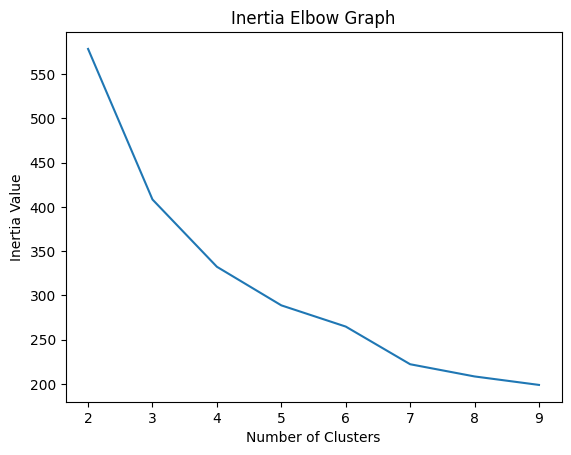

Processing Cluster 2
Completed Cluster  2
Processing Cluster 3
Completed Cluster  3
Processing Cluster 4
Completed Cluster  4
Cluster		Silhouette Score
-------		----------------
2 		 0.8103373624179669
3 		 0.707305197390467
4 		 0.5410513772714612


In [87]:
# Create the clusters.

my_data = create_clusters(X)

# Print the Elbow curve.

print_elbow_curve(my_data)

# Verify by calculating the silhouette scores.

calculate_silhouette_scores_for_clusters(X, 5)


dict_keys([1, 0])


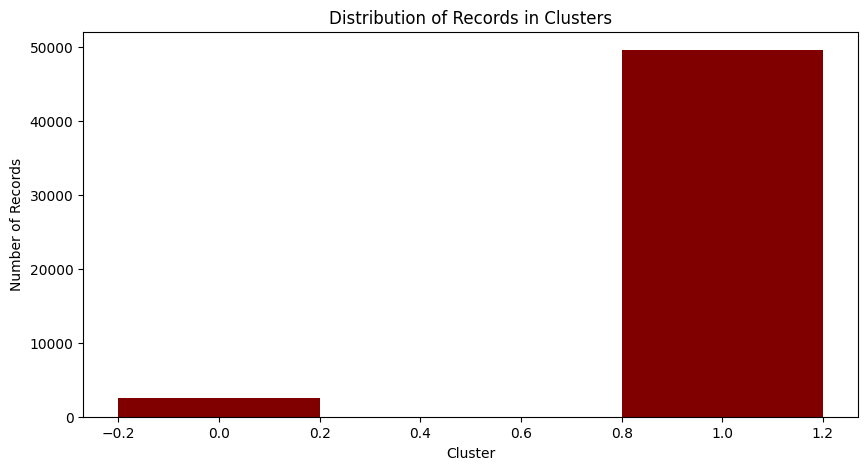

In [88]:
# Build the clusters based on the number of clusters above.

cluster_dict = build_clusters(X, 2)

# Plot the cluster distribution.

plot_cluster_distribution(cluster_dict)

As these clusters are based on the monthly sales, the likelihood that the small cluster represents the monthly sales from the high-sales stores like Vancouver.

In [89]:
# Run the data through the different Regression ML models to
# evaluate performance.

calculate_HistGradientBoostingRegressor(X_train, X_test, y_train, y_test)
calculate_RandomForestRegressor(X_train, X_test, y_train, y_test)
calculate_LinearRegression(X_train, X_test, y_train, y_test)


HistGradientBoostingRegressor
-----------------------------
Predicted Sales 1-5: [152.46642176 299.98485419 222.12073807 168.63803821  84.70008132]
Actual Sales 1-5:    [153.         286.         223.06671241 187.          80.        ]
RMSE:  588.3693409607241

RandomForestRegressor
---------------------
Predicted Sales 1-5: [119.00308537 449.46464701 119.00308537 119.00308537 119.00308537]
Actual Sales 1-5:    [153.         286.         223.06671241 187.          80.        ]
RMSE:  548.6785285614685

LinearRegression
----------------
Predicted Sales 1-5: [153.         286.         223.06671241 187.          80.        ]
Actual Sales 1-5:    [153.         286.         223.06671241 187.          80.        ]
RMSE:  590.1668822002466


The Random Forest Regressor appears to perform worse than the HistGradientBoostingRegressor for actual predictions.

In [90]:
# Now, put it through cross validation to see if the scores are better.

#enr = RandomForestRegressor()
#enr = LinearRegression()
enr = HistGradientBoostingRegressor()
scores = cross_val_score(enr, X, np.ravel(y), cv=5, scoring='neg_mean_squared_error')
display_scores(scores)

Scores: [44.89901561 72.28912129 37.08545865 47.90386508 27.94589437]
Mean: 46.02467100027373
Standard deviation: 14.841640755128388


##Hyperparameters

Conduct a search for the best hyperparameters on the RandomForestRegressor as it didn't appear to do as well as the others.

In [91]:
# Hyperparameter Search for RandomForestRegressor.

estimator = RandomForestRegressor()
param_grid = {
            "n_estimators"      : [4, 5, 10],  # Add all 5 estimators
            "max_features"      : ["sqrt", "log2"],
            "min_samples_split" : [2,4,8],
            "bootstrap": [True, False],
            }

grid = GridSearchCV(estimator, param_grid, n_jobs=-1, cv=5)

grid.fit(X_train, y_train.ravel())


GridSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_split': [2, 4, 8],
                         'n_estimators': [4, 5, 10]})

In [92]:
# Print out the best parameters and best estimator.

print(grid.best_params_)
print("\n",grid.best_estimator_)

{'bootstrap': False, 'max_features': 'log2', 'min_samples_split': 4, 'n_estimators': 10}

 RandomForestRegressor(bootstrap=False, max_features='log2', min_samples_split=4,
                      n_estimators=10)


In [93]:
# Calculate the RMSE for the RandomForestRegressor and display
# the predicted vs actuals.

final_model = grid.best_estimator_
display_results(final_model, X_test, y_test)

RMSE: 584.11091213132
Predicted Sales 1-5: [162.77530124 282.8        208.15774852 172.95165972  76.48719149]
Actual Sales 1-5:    [153.         286.         223.06671241 187.          80.        ]


Far better prediction results for the Random Forester Regressor using the optimal hyperparameters.

## Categorical and Numerical

This will tell us if all features together is better at giving us predictive analytics (e.g., store information + monthly sales volumes).

In [94]:
# Create the Transformations for Period Ddata only.

X, y = create_transformations(True, True)

# Train the model.

X_train, X_test, y_train, y_test = generate_train_test_data(X, y)

(41603, 526) (10401, 526) (41603, 1) (10401, 1)


Creating cluster 2
Done cluster 2
Creating cluster 3
Done cluster 3
Creating cluster 4
Done cluster 4
Creating cluster 5
Done cluster 5
Creating cluster 6
Done cluster 6
Creating cluster 7
Done cluster 7
Creating cluster 8
Done cluster 8
Creating cluster 9
Done cluster 9
[2, 146334.5631233818] [3, 130153.49916532196]


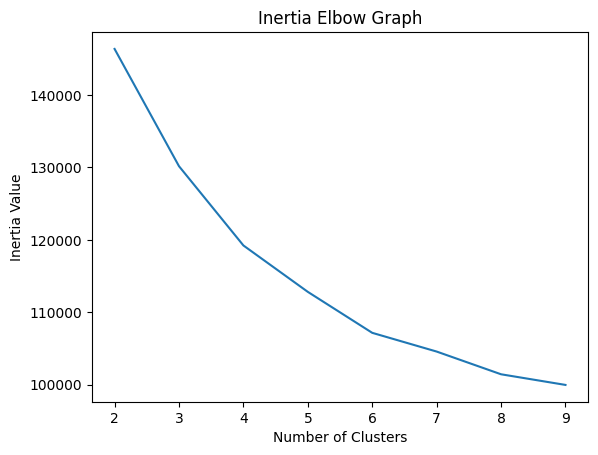

Processing Cluster 2
Completed Cluster  2
Processing Cluster 3
Completed Cluster  3
Processing Cluster 4
Completed Cluster  4
Cluster		Silhouette Score
-------		----------------
2 		 0.20130965853297017
3 		 0.18823596261328213
4 		 0.17702888555444202


In [95]:
# Create the clusters.

my_data = create_clusters(X)

# Print the Elbow curve.

print_elbow_curve(my_data)

# Verify by calculating the silhouette scores.

calculate_silhouette_scores_for_clusters(X, 5)

Same silhouette numbers as just the store data.

dict_keys([1, 0])


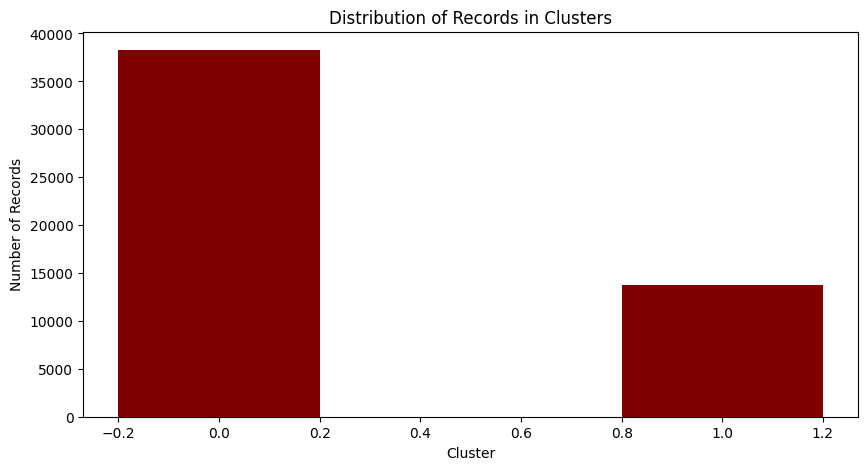

In [96]:
# Build the clusters based on the number of clusters above.

cluster_dict = build_clusters(X, 2)

# Plot the cluster distribution.

plot_cluster_distribution(cluster_dict)

In [97]:
# Run the data through the different Regression ML models to
# evaluate performance.

calculate_HistGradientBoostingRegressor(X_train, X_test, y_train, y_test)
calculate_RandomForestRegressor(X_train, X_test, y_train, y_test)
calculate_LinearRegression(X_train, X_test, y_train, y_test)


HistGradientBoostingRegressor
-----------------------------
Predicted Sales 1-5: [158.61959955 277.66167982 231.36368371 166.51703043  77.75144926]
Actual Sales 1-5:    [153.         286.         223.06671241 187.          80.        ]
RMSE:  590.6528342366971

RandomForestRegressor
---------------------
Predicted Sales 1-5: [119.00308537 449.46464701 119.00308537 119.00308537 119.00308537]
Actual Sales 1-5:    [153.         286.         223.06671241 187.          80.        ]
RMSE:  548.6785285614684

LinearRegression
----------------
Predicted Sales 1-5: [153.         286.         223.06671241 187.          80.        ]
Actual Sales 1-5:    [153.         286.         223.06671241 187.          80.        ]
RMSE:  590.2125284649425


### Analysis Summary

Combining both the store and monthly features does not give us better predictive analytics than just the monthly sales by itself.  

Therefore, the more influential features in this data set are the monthly sales.  

As certain months have the highest correlation to the total sales, can we better predict total sales for the year based on a couple of high-correlative months regardless of a particular store? (e.g., if sales are strong in June and August, 2023 for a store, they will have a higher sales volume for the year compared to a store that has low June and August, 2023 sales).

# Forecasting

Since we only have a single year's worth of data, it is not possible to identify seasonality. We will instead plot the highest 10 stores with their total sales per month.

<ipython-input-98-f6f28ca5a08f>:4: FutureWarning:

The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.

<ipython-input-98-f6f28ca5a08f>:16: FutureWarning:

The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.



<function matplotlib.pyplot.show(close=None, block=None)>

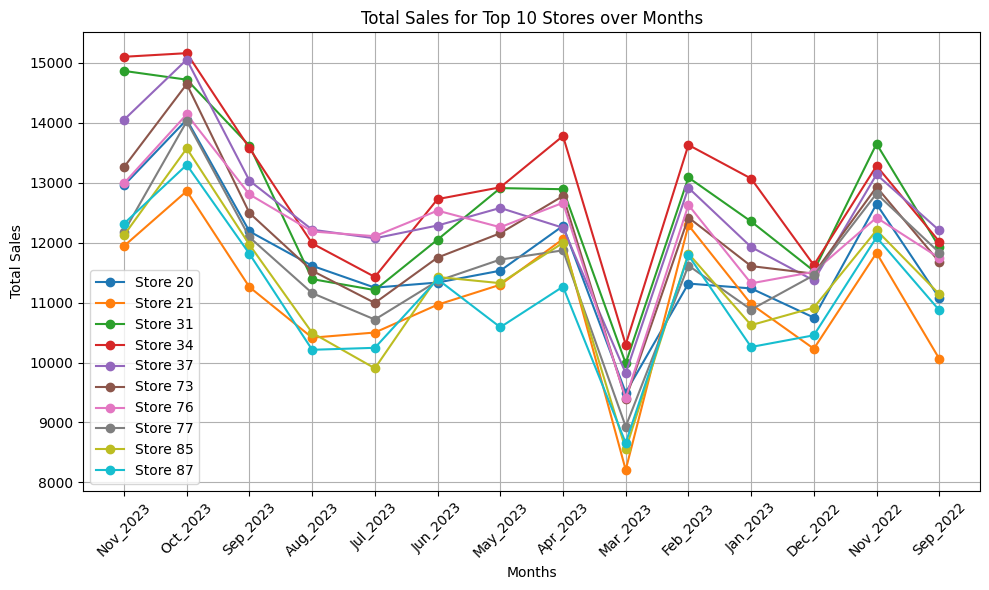

In [98]:
# Assuming 'df' is your DataFrame with columns representing the 14 months of data

# Calculate total sales for each store over the last 14 months
store_sales = df.groupby('Store').sum().iloc[:, -14:]

# Summing across columns (months) to get total sales for each store
total_sales_per_store = store_sales.sum(axis=1)

# Select the top 10 stores with the highest total sales
top_10_stores = total_sales_per_store.nlargest(10)

# Filter data for the top 10 stores
top_10_store_data = df[df['Store'].isin(top_10_stores.index)]

# Group by store and sum across the columns representing the 14 months to get total sales for each store
top_10_sales = top_10_store_data.groupby('Store').sum().iloc[:, -14:]

# Transpose the data for easier plotting
top_10_sales = top_10_sales.T

# Get the months as a list for labeling the x-axis
months = top_10_sales.index

# Plotting total sales for the top 10 stores over the months
plt.figure(figsize=(10, 6))
for store in top_10_sales.columns:
    plt.plot(months, top_10_sales[store], marker='o', label=f'Store {store}')

plt.title('Total Sales for Top 10 Stores over Months')
plt.xlabel('Months')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show


The general shape of the total sales seems to be the same. We can explore if we are able to predict one store's volume if we use another similar store.

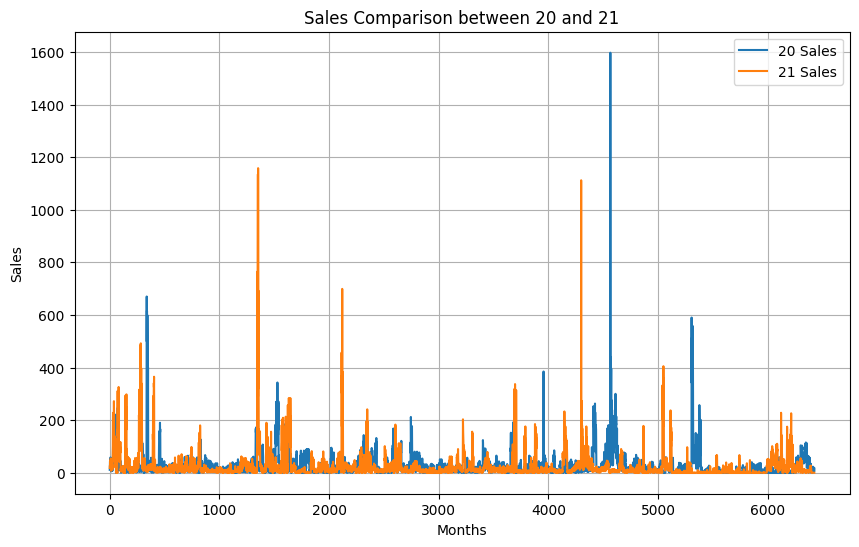

R-squared value: 0.0004


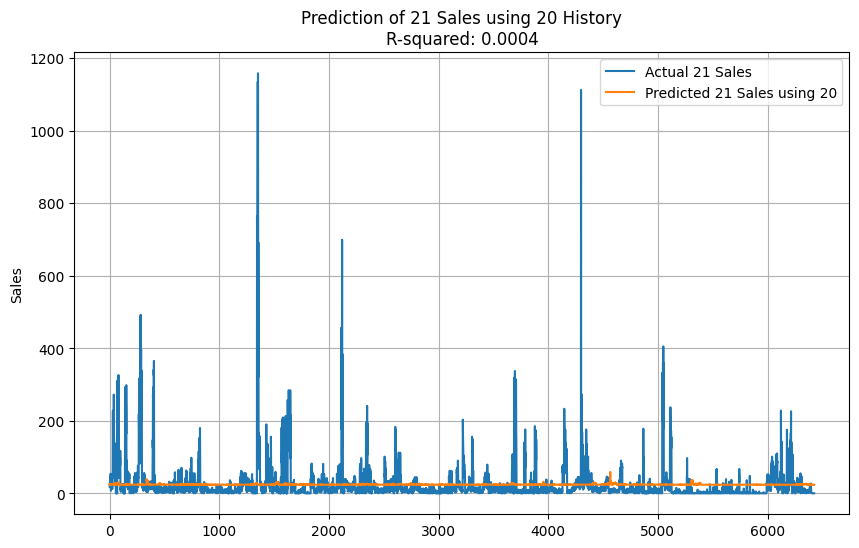

In [99]:
# Choose two stores for comparison (change 'Store_A' and 'Store_B' to the actual store names)
store_A = 20
store_B = 21

# Extract sales data for Store A and Store B
sales_store_A = df[df['Store'] == store_A].iloc[:, -14:].values.reshape(-1, 1)
sales_store_B = df[df['Store'] == store_B].iloc[:, -14:].values.reshape(-1, 1)

# Ensure both sales data have the same number of samples (if different, truncate to the smaller size)
min_samples = min(len(sales_store_A), len(sales_store_B))
sales_store_A = sales_store_A[:min_samples]
sales_store_B = sales_store_B[:min_samples]

# Plotting sales for Store A and Store B over the last 14 months
plt.figure(figsize=(10, 6))
plt.plot(sales_store_A, label=f'{store_A} Sales')
plt.plot(sales_store_B, label=f'{store_B} Sales')
plt.title(f'Sales Comparison between {store_A} and {store_B}')
plt.xlabel('Months')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

# Fit the linear regression model
regression_model = LinearRegression()

regression_model.fit(sales_store_A, sales_store_B)

# Predict Store B's sales using Store A's sales history
predicted_sales_B = regression_model.predict(sales_store_A)

# Calculate R-squared value
r_squared = r2_score(sales_store_B, predicted_sales_B)
print(f"R-squared value: {r_squared:.4f}")

# Plotting actual sales of Store B vs. predicted sales of Store B using Store A's history
plt.figure(figsize=(10, 6))
plt.plot(sales_store_B, label=f'Actual {store_B} Sales')
plt.plot(predicted_sales_B, label=f'Predicted {store_B} Sales using {store_A}')
plt.title(f'Prediction of {store_B} Sales using {store_A} History\nR-squared: {r_squared:.4f}')

plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

In [100]:
# Assuming 'df' is your DataFrame containing sales data for both Store 20 and Store 21

# Find common items between Store 20 and Store 21
common_items = set(df[df['Store'] == 20]['ITEM']).intersection(set(df[df['Store'] == 21]['ITEM']))

# Filter sales data for common items in both stores
store_20_filtered = df[(df['Store'] == 20) & (df['ITEM'].isin(common_items))]
store_21_filtered = df[(df['Store'] == 21) & (df['ITEM'].isin(common_items))]

# Group and sum the sales data by 'ITEM' for both stores
store_20_sum_by_item = store_20_filtered.groupby('ITEM').sum()
store_21_sum_by_item = store_21_filtered.groupby('ITEM').sum()

# Prepare the data for training the model
X = store_20_sum_by_item.values  # Features (summed sales data for Store 20 by ITEM)
y = store_21_sum_by_item.values  # Target variable (summed sales data for Store 21 by ITEM)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
y_train = scaler.fit_transform(y_train)
y_test = scaler.transform(y_test)

# Build the Neural Network model
model = Sequential()
model.add(Dense(64, input_shape=(X_train.shape[1],), activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(y_train.shape[1]))  # Output layer for regression with the same number of outputs as columns in y_train

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model
mse = model.evaluate(X_test, y_test)
print(f"Mean Squared Error (MSE): {mse}")

# Make predictions
predictions = model.predict(X_test)
# You can now use 'predictions' to compare with 'y_test' or make predictions on new data


<ipython-input-100-7bc9e2aa336e>:11: FutureWarning:

The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.

<ipython-input-100-7bc9e2aa336e>:12: FutureWarning:

The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.



Epoch 1/50
10/10 [==============================] - 1s 34ms/step - loss: 1.0204 - val_loss: 1.1472
Epoch 2/50
10/10 [==============================] - 0s 7ms/step - loss: 0.9247 - val_loss: 1.1145
Epoch 3/50
10/10 [==============================] - 0s 9ms/step - loss: 0.8555 - val_loss: 1.0762
Epoch 4/50
10/10 [==============================] - 0s 7ms/step - loss: 0.7870 - val_loss: 1.0304
Epoch 5/50
10/10 [==============================] - 0s 7ms/step - loss: 0.7259 - val_loss: 0.9879
Epoch 6/50
10/10 [==============================] - 0s 8ms/step - loss: 0.6829 - val_loss: 0.9522
Epoch 7/50
10/10 [==============================] - 0s 7ms/step - loss: 0.6204 - val_loss: 0.9354
Epoch 8/50
10/10 [==============================] - 0s 7ms/step - loss: 0.5744 - val_loss: 0.9150
Epoch 9/50
10/10 [==============================] - 0s 9ms/step - loss: 0.5470 - val_loss: 0.8907
Epoch 10/50
10/10 [==============================] - 0s 9ms/step - loss: 0.5187 - val_loss: 0.8888
Epoch 11/50
10/10 

In [101]:
len(y_test)
y_test

array([[-0.40772011, -0.40772011, -0.40975709, ..., -0.53840439,
        -0.46166854, -0.53151232],
       [-0.40772011, -0.40772011, -0.40975709, ..., -0.53840439,
        -0.46166854, -0.53151232],
       [-0.40772011, -0.40772011, -0.24083652, ..., -0.43392514,
        -0.28164739, -0.22133871],
       ...,
       [ 1.68524311,  1.68524311,  1.16683492, ...,  6.27364243,
         2.49018651,  4.76211744],
       [-0.40772011, -0.40772011, -0.29714337, ..., -0.2458625 ,
        -0.37165797, -0.34540815],
       [-0.40772011, -0.40772011, -0.18452966, ..., -0.09959156,
        -0.14663153,  0.10951315]])

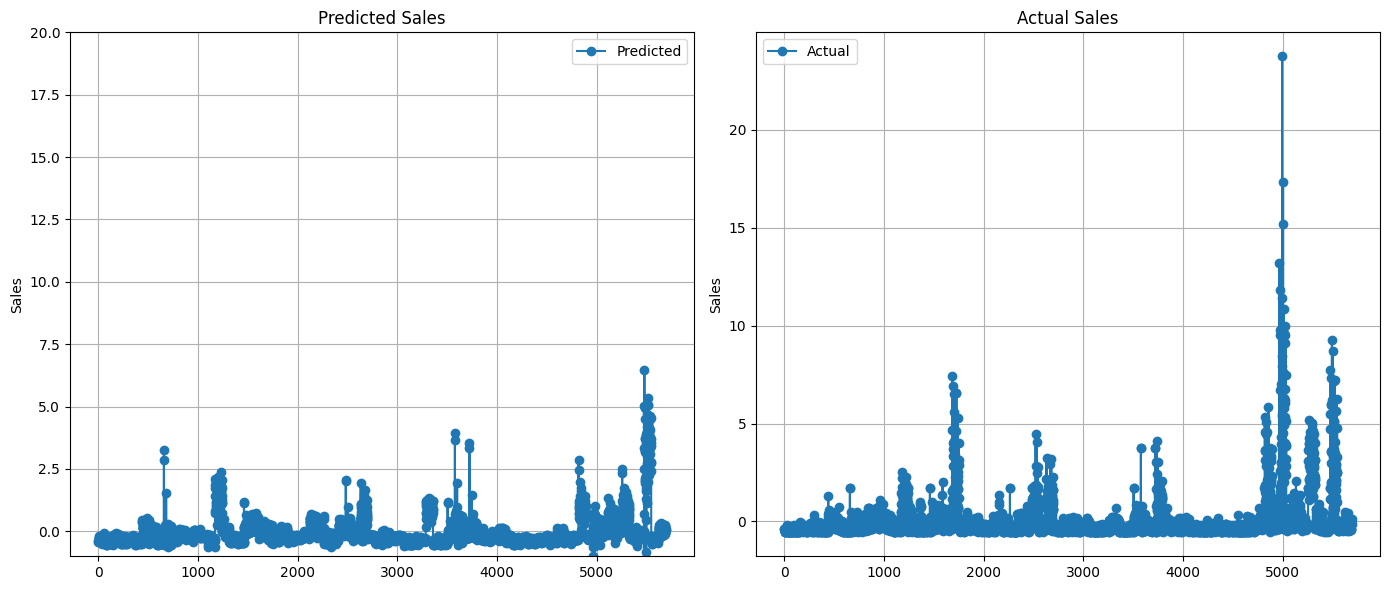

In [102]:
# Assuming 'predictions' and 'y_test' are arrays or series
flattened_predictions = np.ravel(predictions)
flattened_y_test = np.ravel(y_test)


# Assuming 'predictions' contains the predicted values and 'y_test' contains the actual values for each month

# Create a DataFrame to display predictions and actual values for each month
results_df = pd.DataFrame({
    'Predicted': flattened_predictions,  # Use predictions directly if already one-dimensional
    'Actual': flattened_y_test  # Use y_test directly if already one-dimensional
})

# Create a figure with two subplots side by side
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plot 'Predicted' values in the first subplot
axs[0].plot(results_df['Predicted'], marker='o', label='Predicted', alpha=1)
axs[0].set_title('Predicted Sales')
axs[0].set_ylabel('Sales')
axs[0].legend()
axs[0].grid(True)
axs[0].set_ylim(-1, 20)  # Set y-axis limits
# Plot 'Actual' values in the second subplot
axs[1].plot(results_df['Actual'], marker='o', label='Actual', alpha=1)
axs[1].set_title('Actual Sales')
axs[1].set_ylabel('Sales')
axs[1].legend()
axs[1].grid(True)
axs[0].set_ylim(-1, 20)  # Set y-axis limits
plt.tight_layout()
plt.show()


Neither of the methods used managed to create a good prediction model.

While NN was much more accurate then running a linear regression, it is still way off for many products.